In [76]:
import numpy as np
import matplotlib.pyplot as plt
import math

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
import lib_plot


from lib_equations import root_finder, herm_coeff, herm_func, trapezoidal, Simpson


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


H_6(x) =  -120 + 720x^2 - 480x^4 + 64x^6


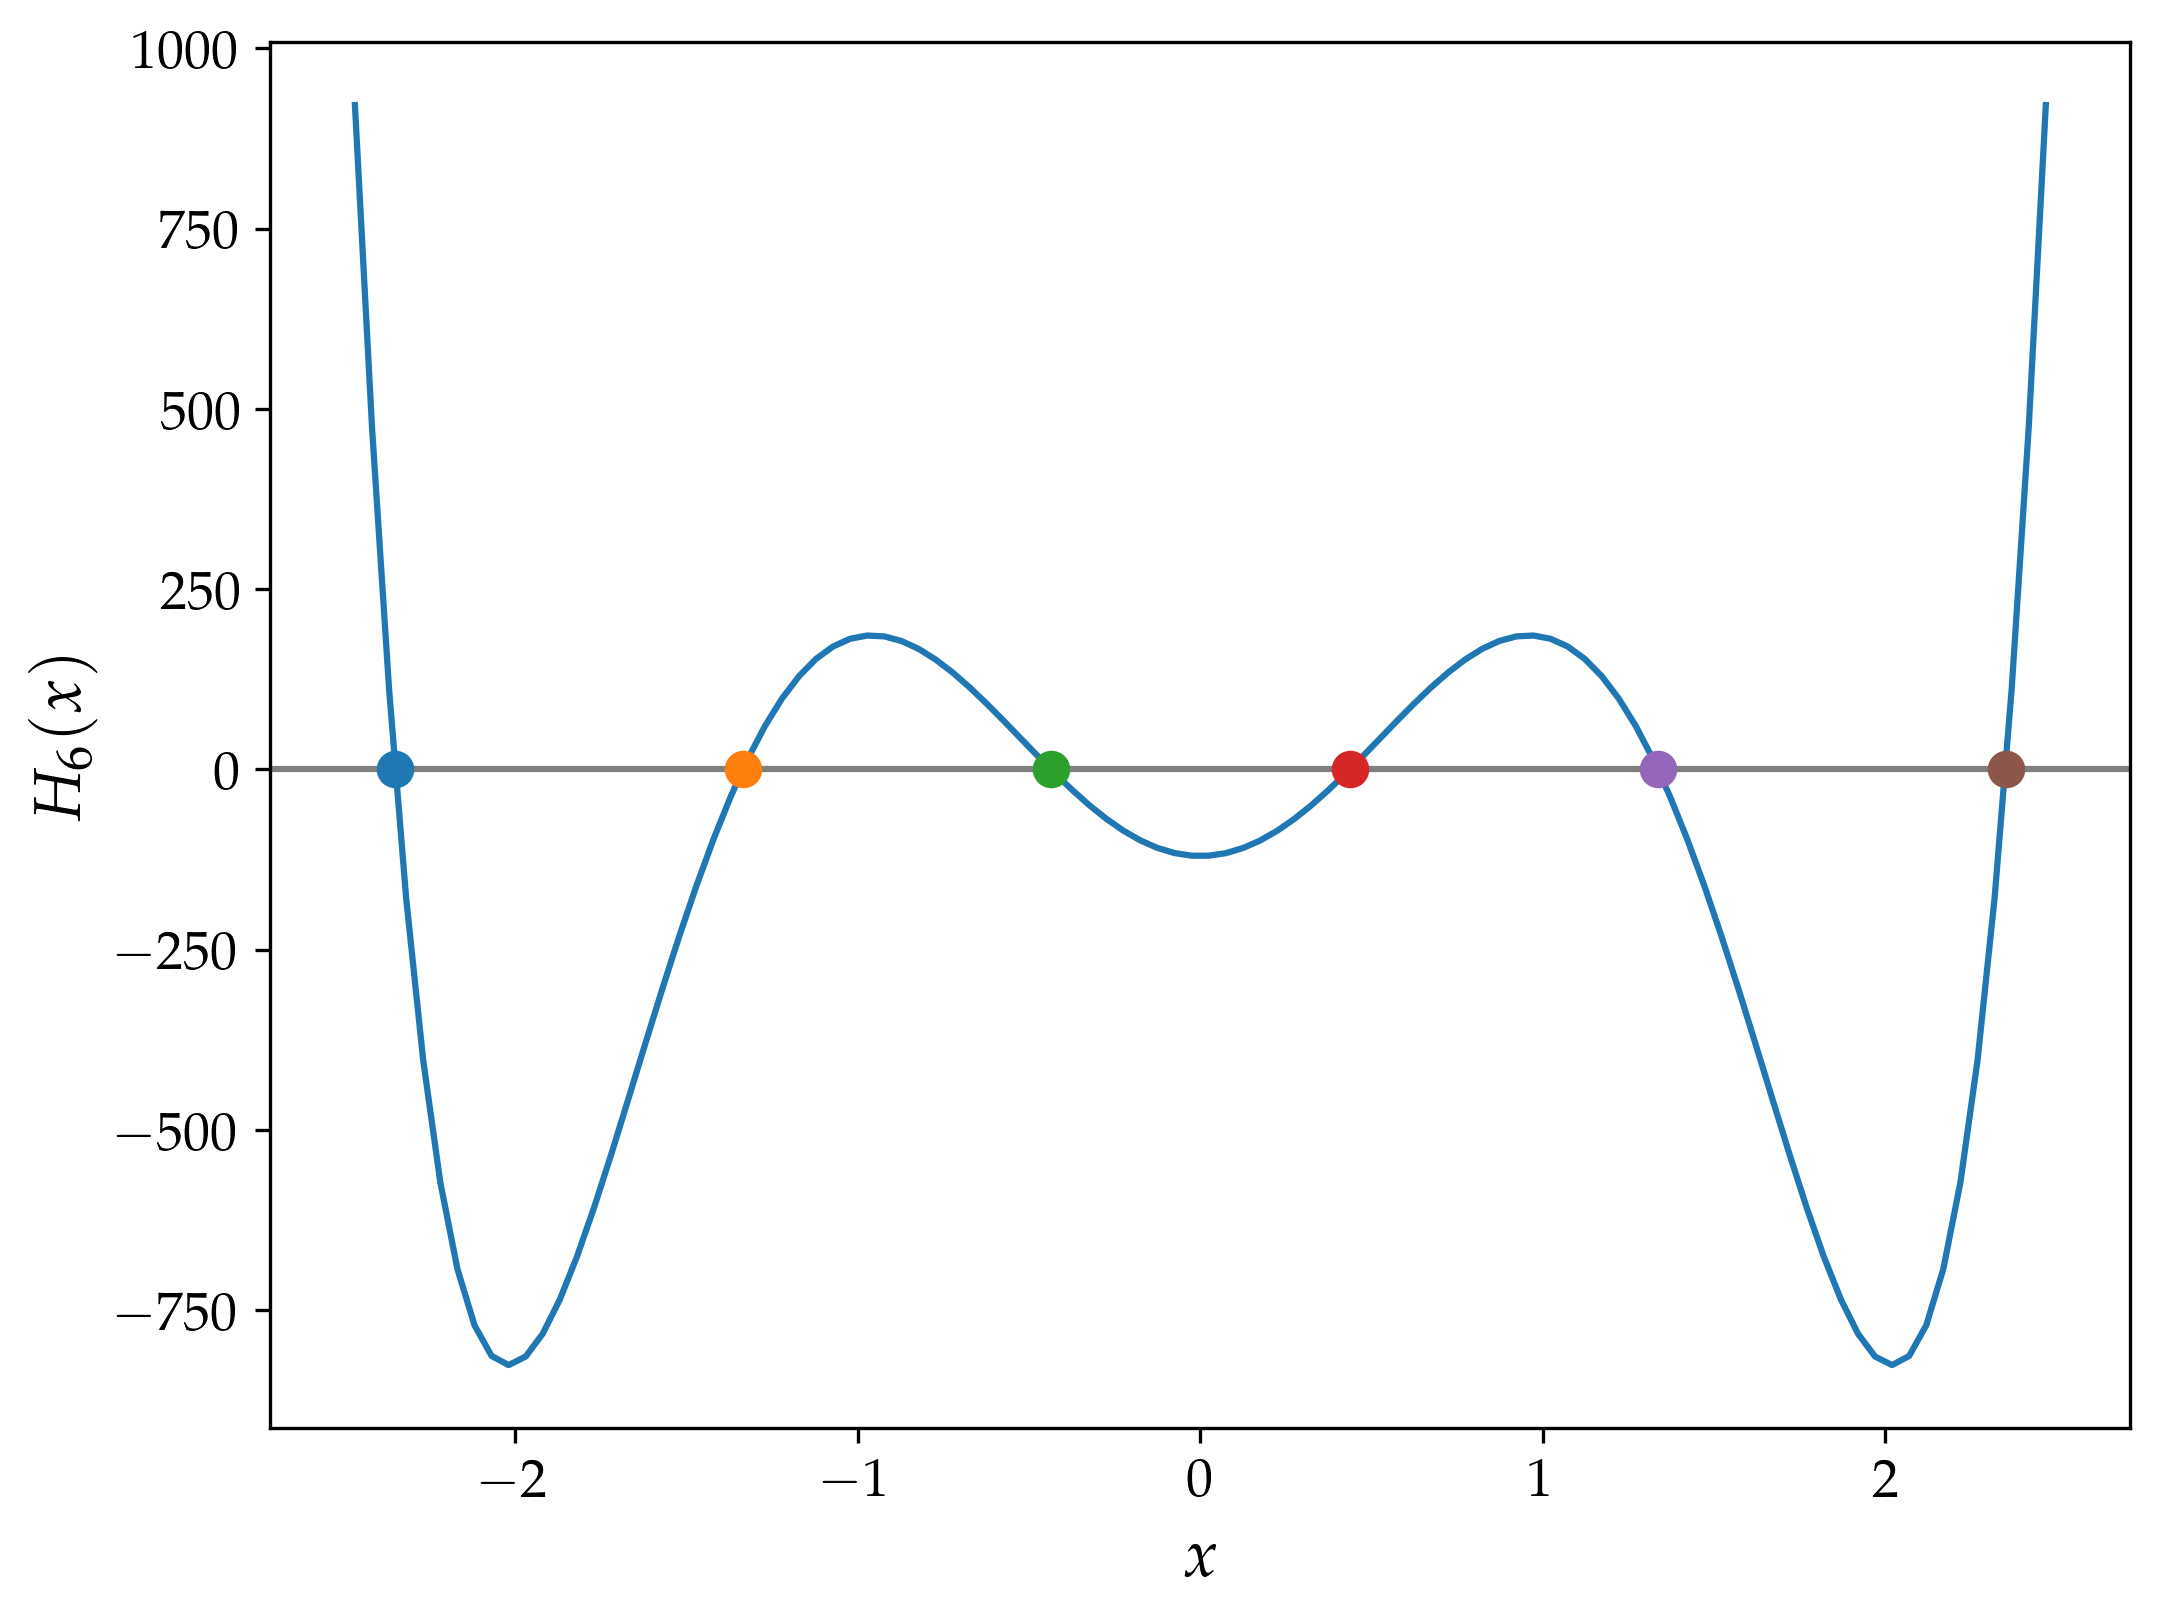

In [77]:
deg = 6
H_coeff = np.flip(herm_coeff(deg))
H_roots = root_finder(herm_coeff(deg))

coeffs = H_coeff
terms = []
for i, c in enumerate(coeffs):
    if np.isclose(c, 0):
        continue
    coeff = int(c) if np.isclose(c, round(c)) else float(c)
    sign = "+" if c > 0 else "-"
    abs_coeff = abs(coeff)
    if i == 0:
        term = f"{abs_coeff}"
    elif i == 1:
        term = f"{abs_coeff}x"
    else:
        term = f"{abs_coeff}x^{i}"
    if terms:
        terms.append(f" {sign} {term}")
    else:
        terms.append(f"{'-' if c < 0 else ''}{term}")
poly_str = "".join(terms) if terms else "0"
print(f'H_{deg}(x) = ', poly_str)

limx = max(H_roots)*1.05
xcoo = np.linspace(-limx, limx, 100, dtype=float)
ycoo = herm_func(xcoo, deg)

plt.plot(xcoo, ycoo)
for i, root in enumerate(H_roots):
    plt.scatter(root, 0, marker='o', zorder=3, lw=3, label=rf'$x_{i}$')

plt.axhline(color='black', alpha=0.5)
plt.ylim()

plt.xlabel(rf'$x$')
plt.ylabel(rf'$H_{deg}(x)$')
# plt.legend()
plt.show()



In [78]:
from first_ex import deg

data = np.genfromtxt('txts/res_test_gauss.txt')

xcoo_load, ycoo_load = (data[:-1, :][:, 0], data[:-1, :][:, 1])
res = data[-1, 0]

print(f'Result (n={deg}) = ', res)


Result (n=15) =  18.51455050647169


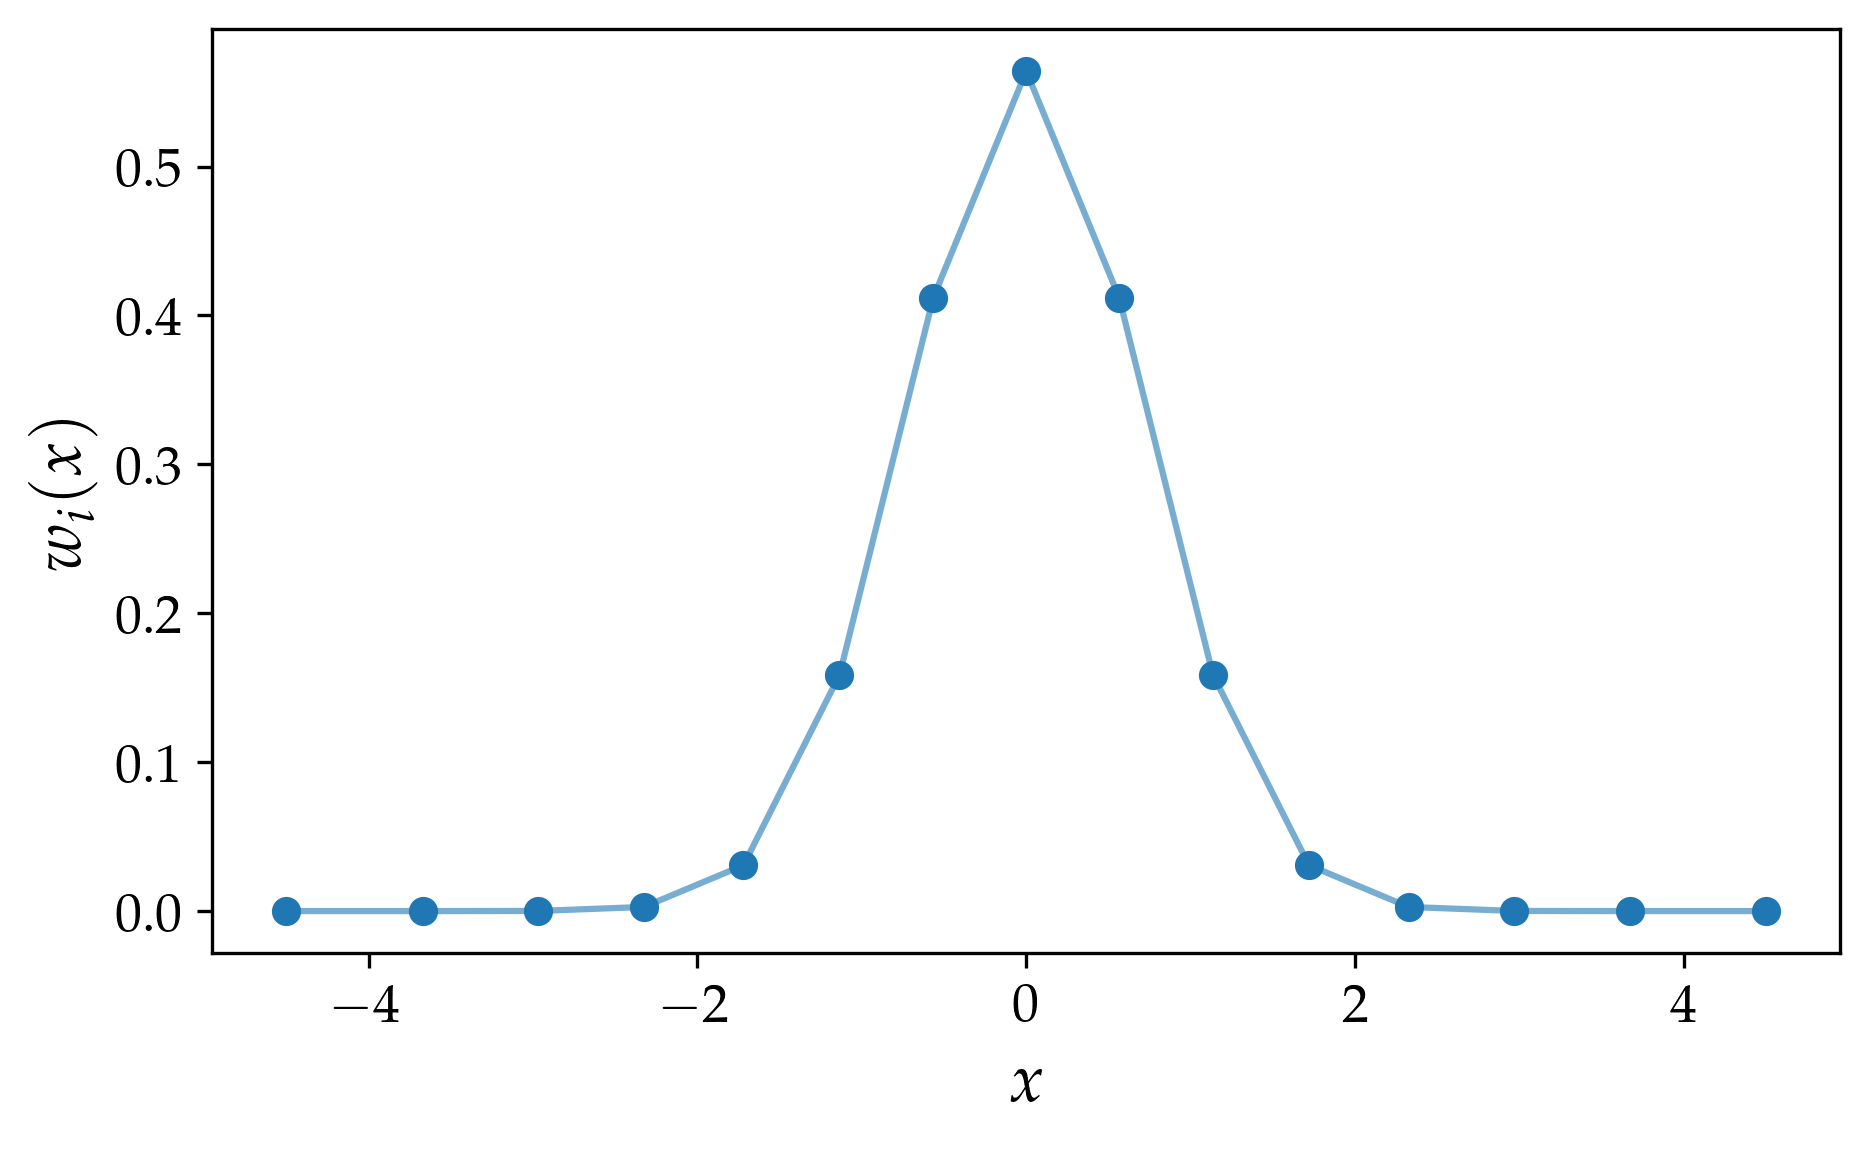

In [79]:
plt.figure(figsize=(7,4))
plt.plot(xcoo_load, ycoo_load, alpha=0.6)
plt.scatter(xcoo_load, ycoo_load, zorder=3, label='Radici ')
plt.xlabel(r'$x$')
plt.ylabel(rf'$w_i(x)$')

plt.savefig('plots/weight_example.png')
plt.show()


## **Problems with weight function**

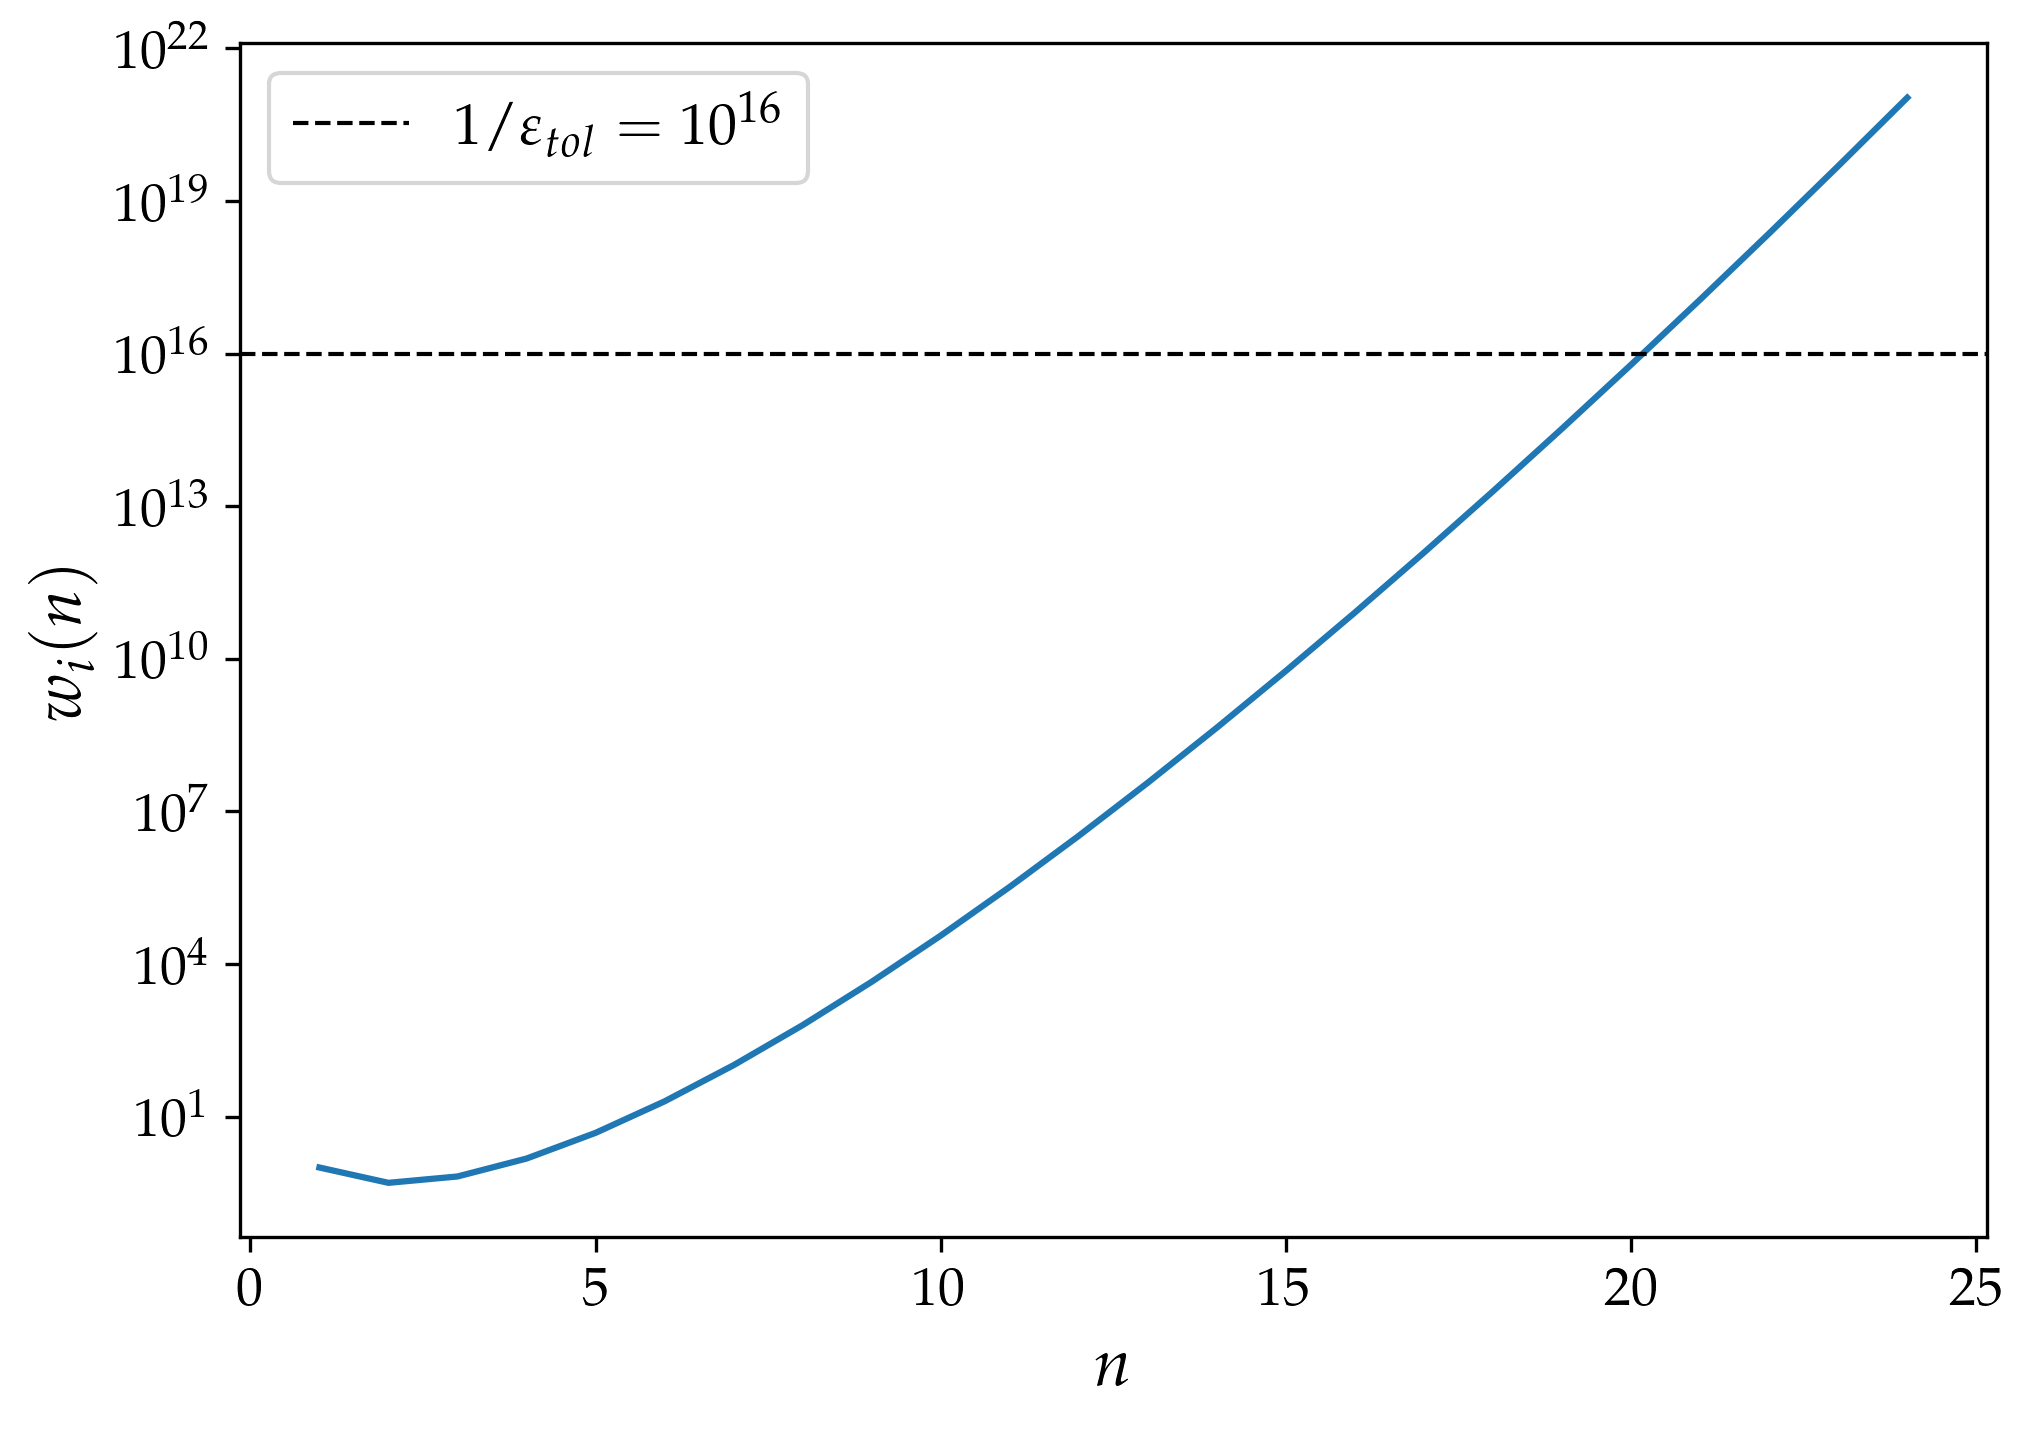

In [80]:
# weight functions w_i grow following
# w_i ~ (n-1)! / n
# this could lead to numerical instability when working with n big, because of the factorial

def calc_(n):
    # asymptotic function weight
    from math import factorial
    return factorial(n-1)/ n

as_fw = np.vectorize(calc_)

xcoo = np.arange(1, 25)
ycoo = as_fw(xcoo)
epsilon = 1e-16

plt.figure(figsize=(7,5))
plt.plot(xcoo, ycoo)
plt.axhline(1/epsilon, ls= '--', lw=1, color='black', label=rf'$1/\varepsilon_{{tol}}=10^{{16}}$')

plt.xlabel(r'$n$')
plt.ylabel(r'$w_i(n)$')

plt.yscale('log')
plt.legend()
plt.tight_layout()

plt.savefig('plots/asym_weight')
plt.show()



# **Int_1**

In [81]:
data = np.loadtxt('txts/int1.txt')
from int_1 import n_deg_1, true_1
errs_1 = data[:, 2]
best_ind = np.argmin(data[:, 2])
I_g = data[:, 1][best_ind]

print('n --> res:')
for row in data:
    deg, res, err = row
    if deg < 10:
        print(f'    {int(deg)}  -->   {res}')
    else:
        print(f'    {int(deg)} -->   {res}')
    print(f'       -->   {err:.1e}\n')

n --> res:
    1  -->   1.7724538509055159
       -->   4.3e-01

    3  -->   1.4179630807244132
       -->   7.5e-02

    5  -->   1.3634260391581117
       -->   2.0e-02

    7  -->   1.3500262746455
       -->   6.7e-03

    9  -->   1.345870089401862
       -->   2.6e-03

    11 -->   1.3443774750609365
       -->   1.1e-03

    13 -->   1.3437831874102117
       -->   4.9e-04

    15 -->   1.343527468079525
       -->   2.3e-04

    17 -->   1.3434104959189055
       -->   1.2e-04

    19 -->   -0.00024801178390803074
       -->   1.3e+00

    21 -->   4.544961246854425e-06
       -->   1.3e+00



Results of the study:
     TRUE                --> I = 1.3432934216467347

     Gauss quadrature    --> I = 1.3434104959189055
                             err = 1.17e-04


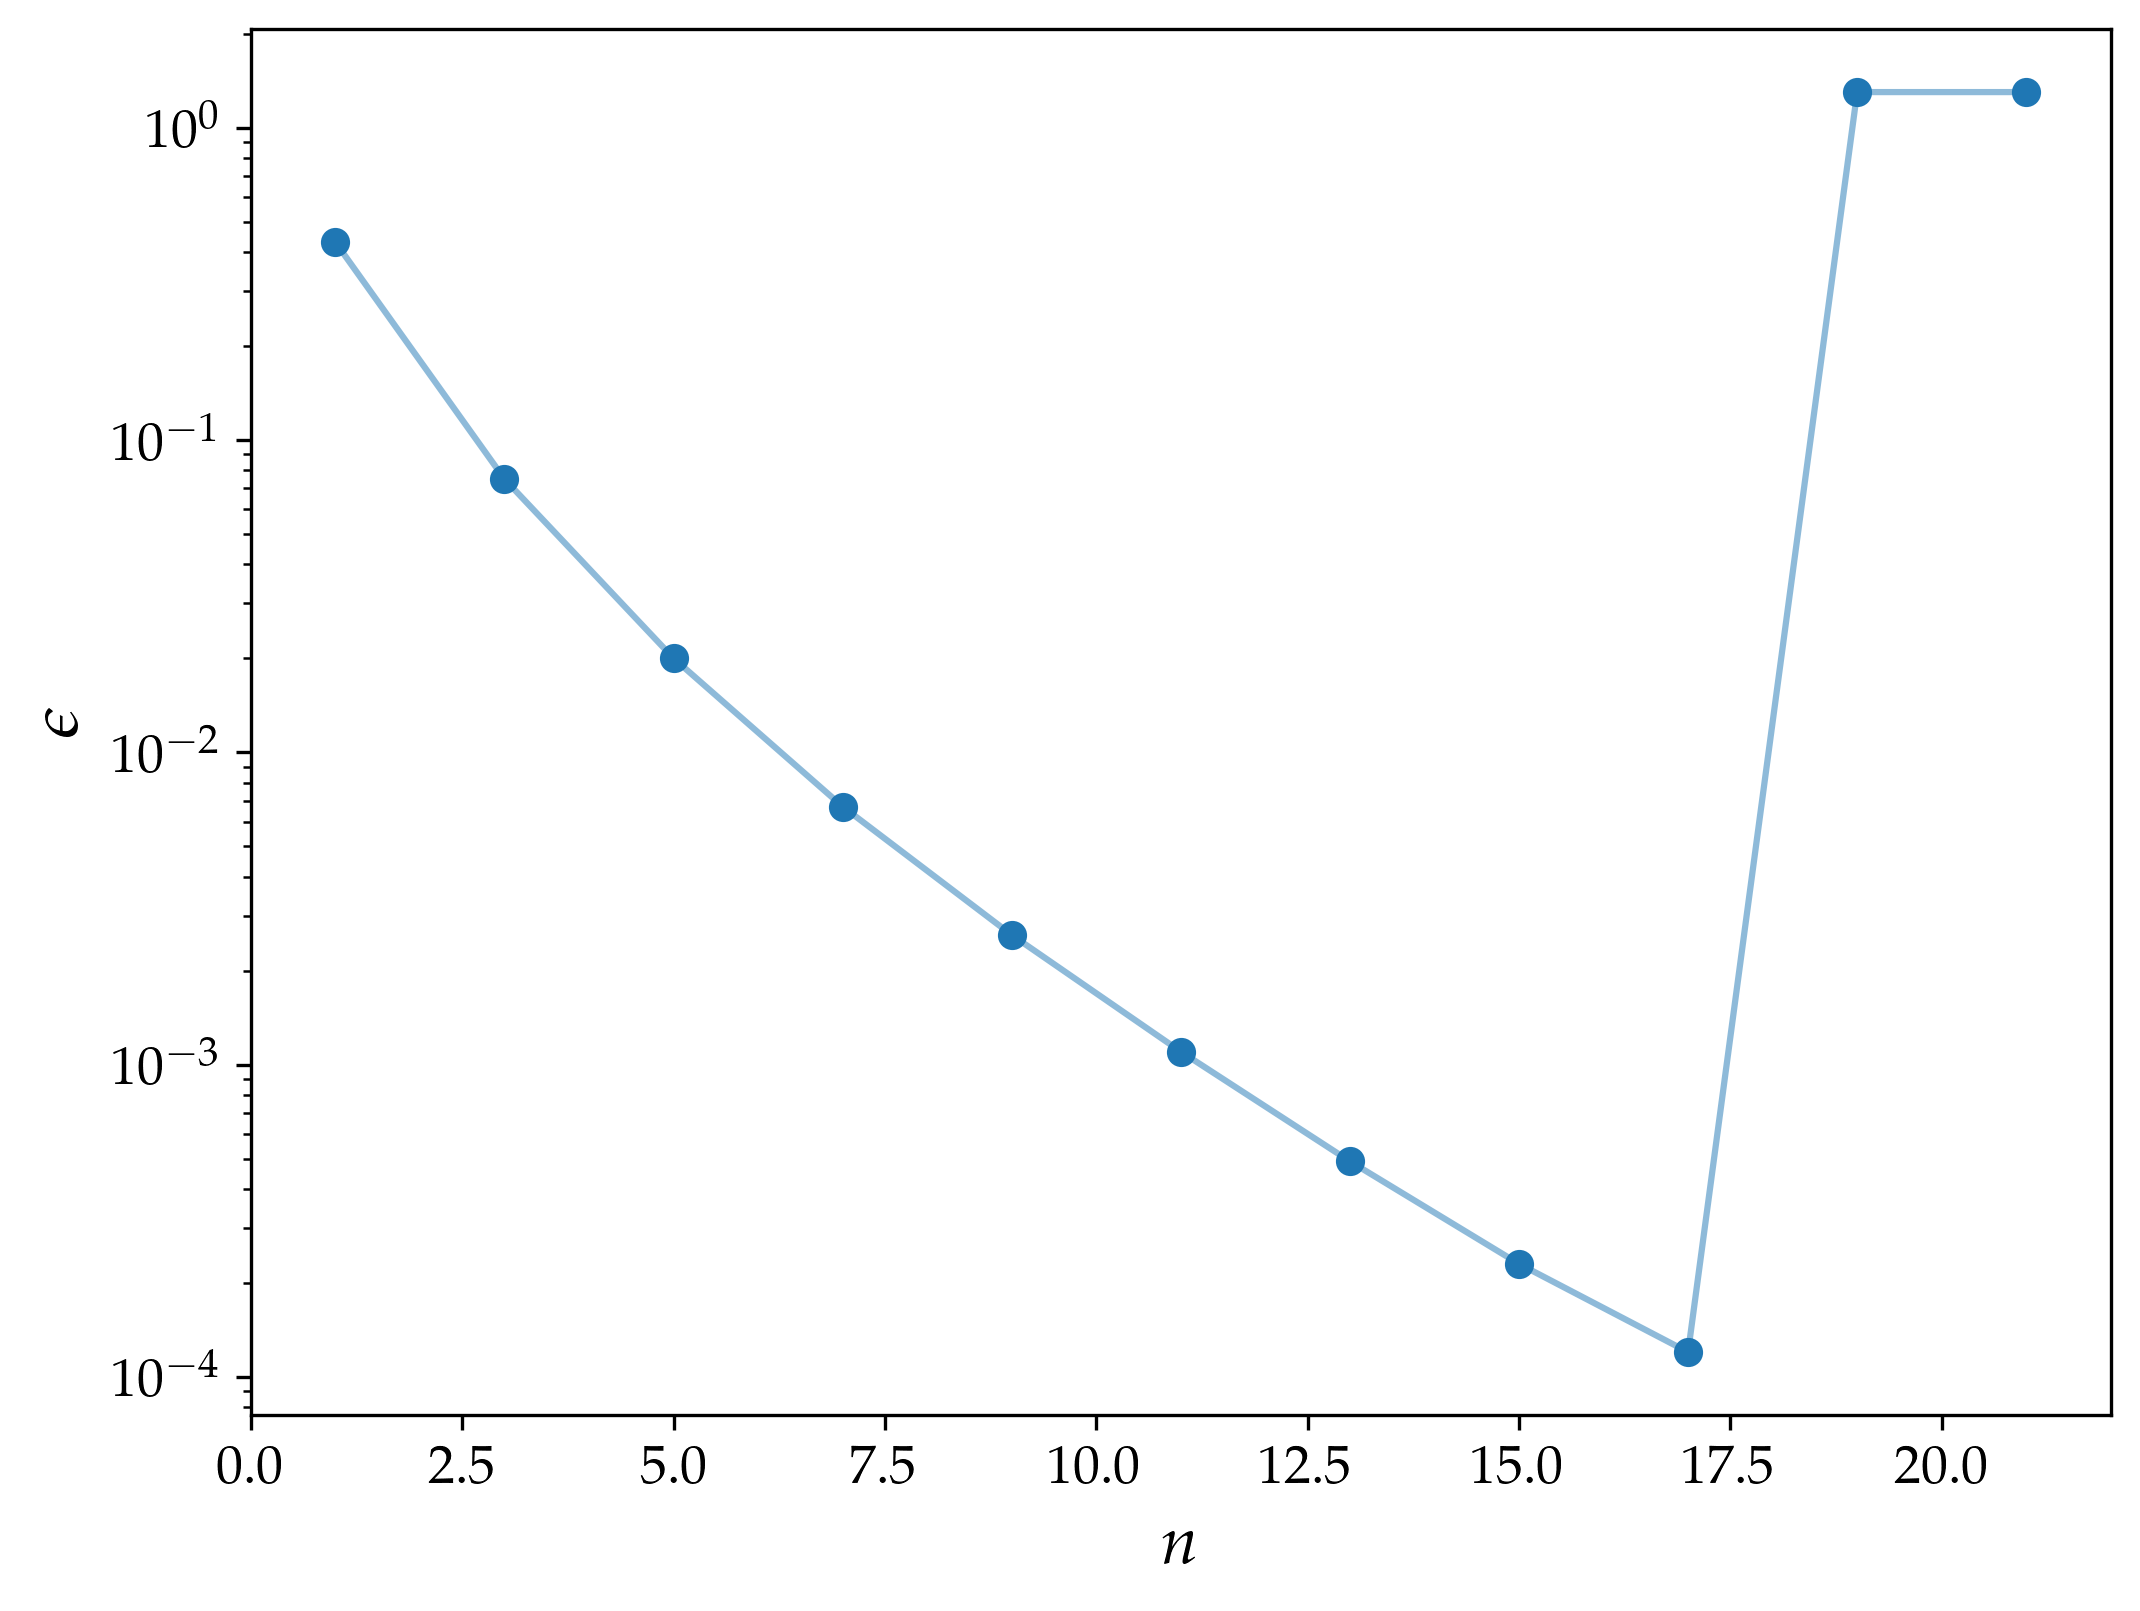

In [82]:
print('Results of the study:')
print('     TRUE                --> I =', true_1)
print()
print('     Gauss quadrature    --> I =', I_g)
print(f'                             err = {abs(true_1 - I_g):.2e}')


plt.plot(n_deg_1, errs_1, alpha=0.5)
plt.scatter(n_deg_1, errs_1)
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_1.png')
plt.show()


# **Int_2**

Results of the study:
     TRUE                --> I = 5.815864198283724

     Gauss quadrature    --> I = 5.8158641982835775
                             err = 1.47e-13

n --> res:
    1  -->   0.0
       -->   5.8e+00

    3  -->   1.4955079367015227
       -->   4.3e+00

    5  -->   10.31599263303481
       -->   4.5e+00

    7  -->   5.8158641982835775
       -->   1.5e-13

    9  -->   5.815864198281439
       -->   2.3e-12

    11 -->   5.815864198285083
       -->   1.4e-12

    13 -->   5.815864197710478
       -->   5.7e-10

    15 -->   5.81586417723752
       -->   2.1e-08

    17 -->   5.7967282793981205
       -->   1.9e-02

    19 -->   -0.0010737323023910623
       -->   5.8e+00

    21 -->   5.0566921528150206e-05
       -->   5.8e+00



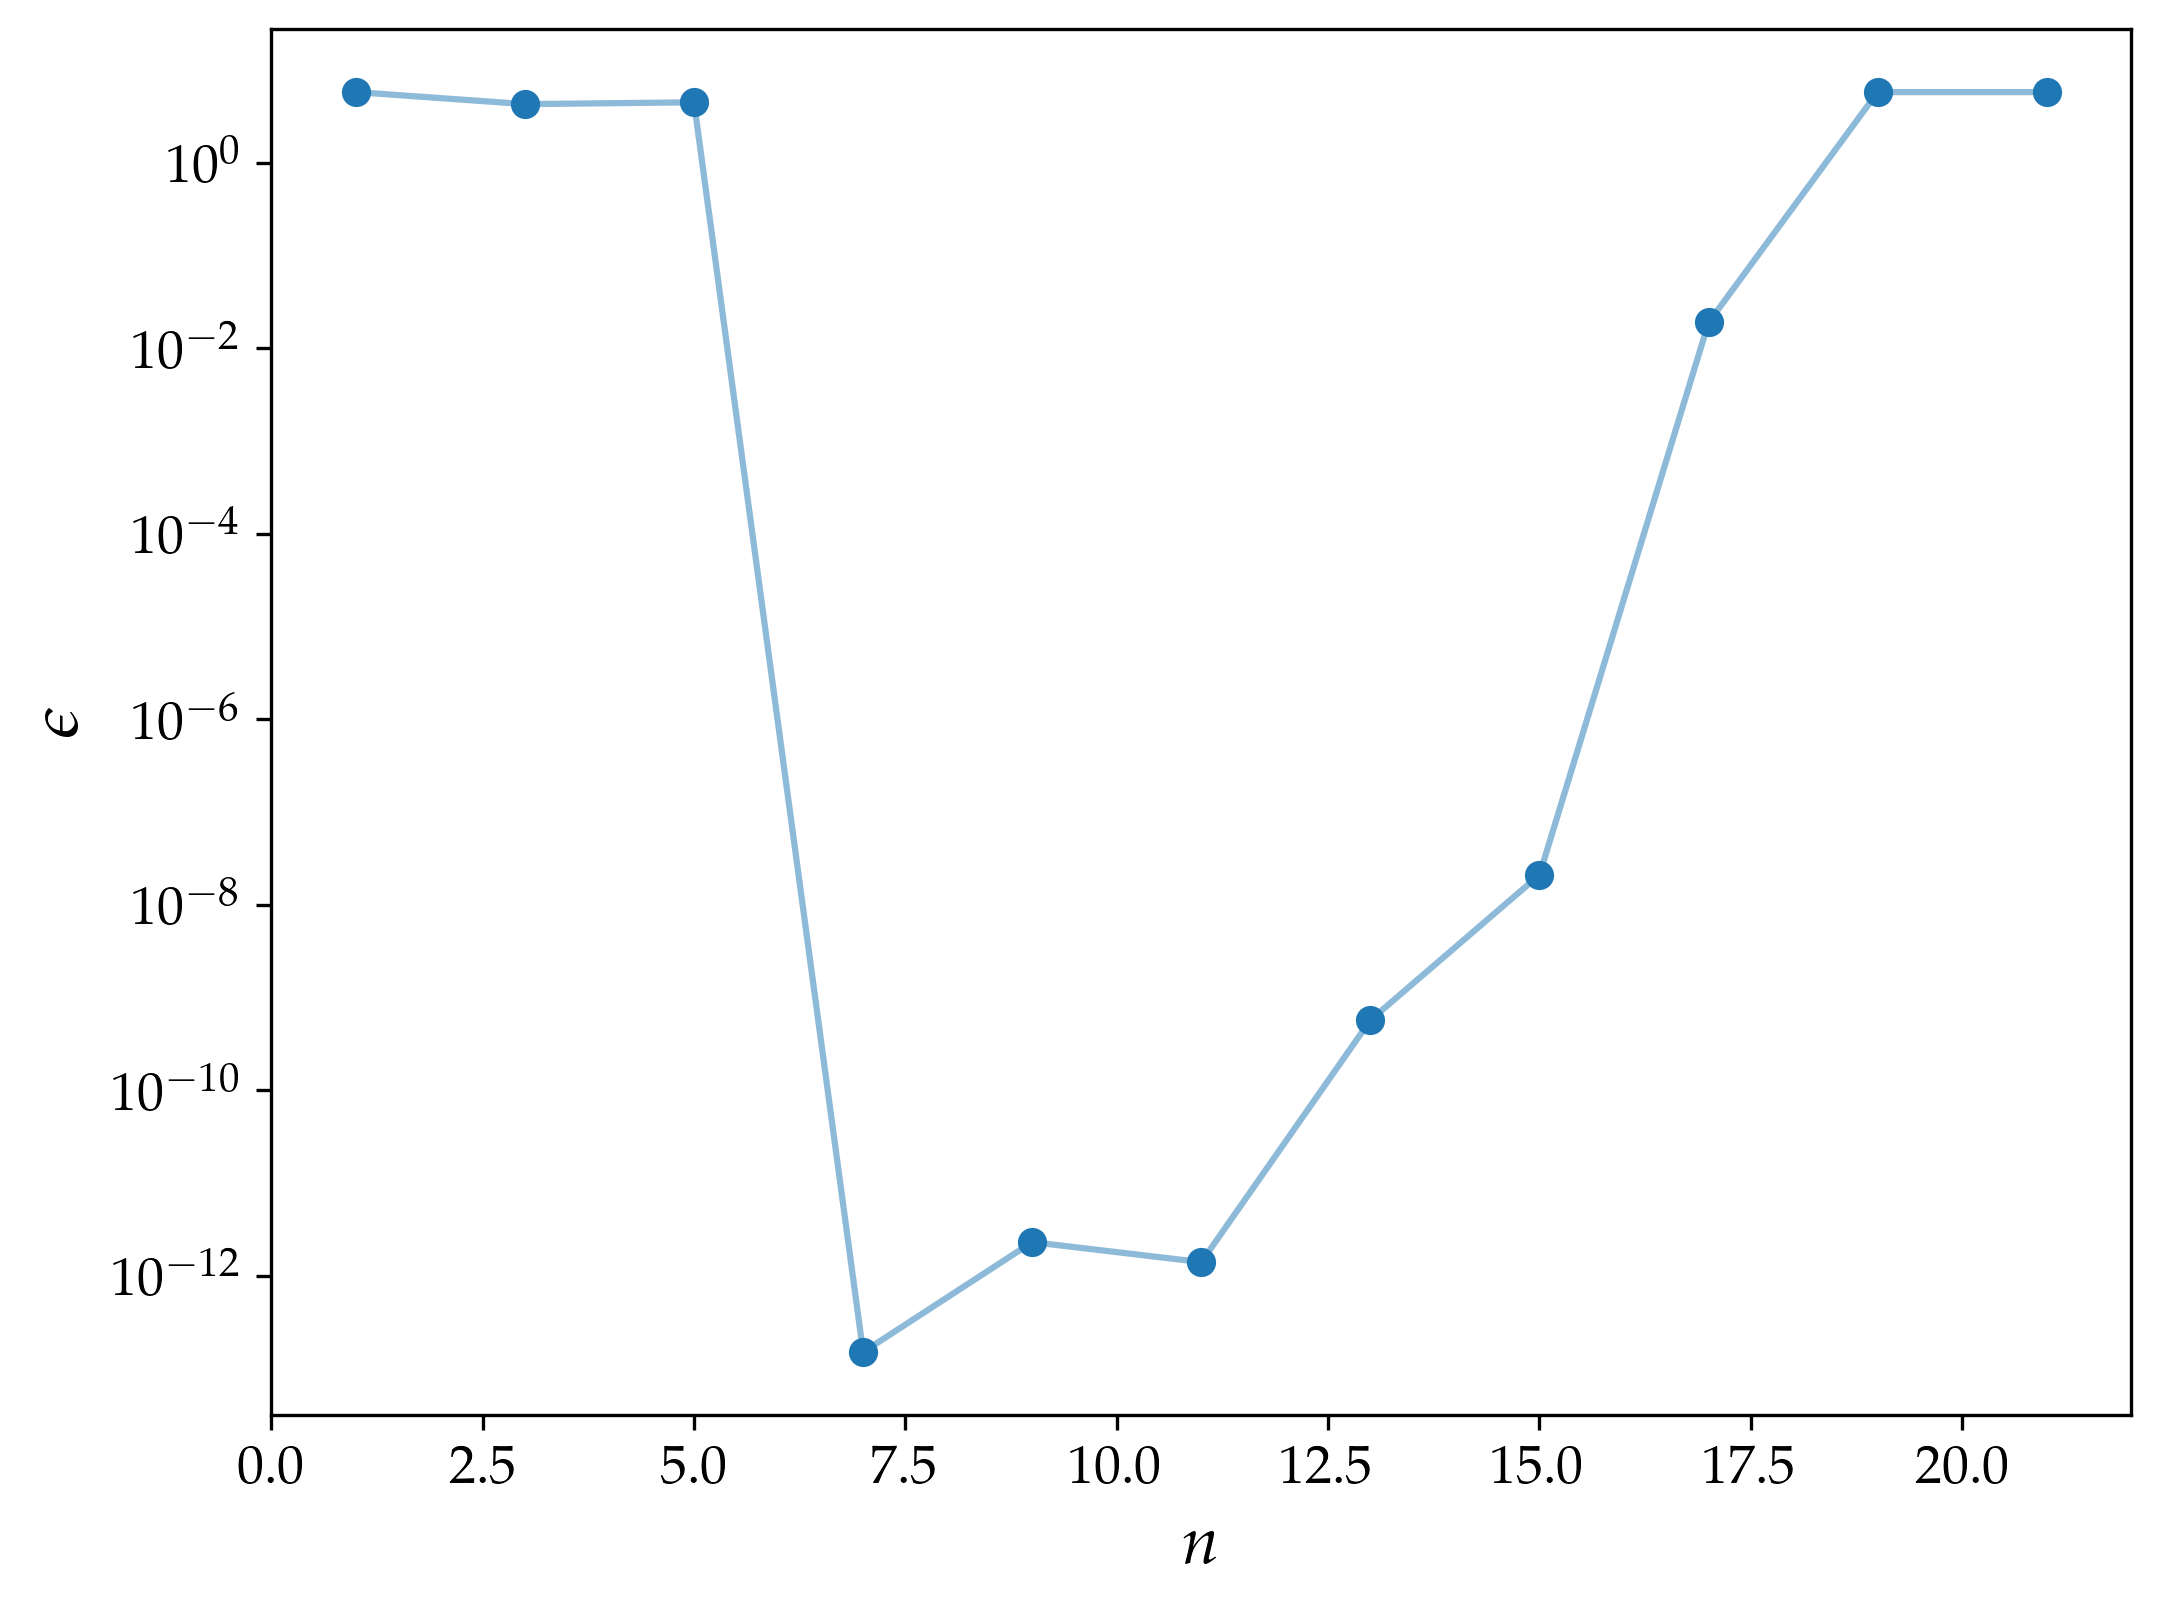

In [83]:
data = np.loadtxt('txts/int2.txt')
from int_2 import n_deg_2, true_2
errs_2 = data[:, 2]
best_ind = np.argmin(data[:, 2])
I_g = data[:, 1][best_ind]

print('Results of the study:')
print('     TRUE                --> I =', true_2)
print()
print('     Gauss quadrature    --> I =', I_g)
print(f'                             err = {abs(true_2 - I_g):.2e}')
print()

print('n --> res:')
for row in data:
    deg, res, err = row
    if deg < 10:
        print(f'    {int(deg)}  -->   {res}')
    else:
        print(f'    {int(deg)} -->   {res}')
    print(f'       -->   {err:.1e}\n')




plt.plot(n_deg_2, errs_2, alpha=0.5)
plt.scatter(n_deg_2, errs_2)
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

plt.savefig('plots/int_2.png')
plt.show()


## **The case of interest of $\int_3 ^\infty dx\ x^5 e^{-x^2}$**

n --> res:
    5  -->   0.0
       -->   6.2e-03

    7  -->   0.0
       -->   6.2e-03

    9  -->   0.01310391579996764
       -->   6.9e-03

    11 -->   0.0009564345363545069
       -->   5.3e-03

    13 -->   0.007425295567897055
       -->   1.2e-03

    15 -->   0.0007078989551652133
       -->   5.5e-03

    17 -->   0.00318777431932447
       -->   3.0e-03

    19 -->   -1.636212352711512e-06
       -->   6.2e-03

    21 -->   1.0428101695977709e-10
       -->   6.2e-03



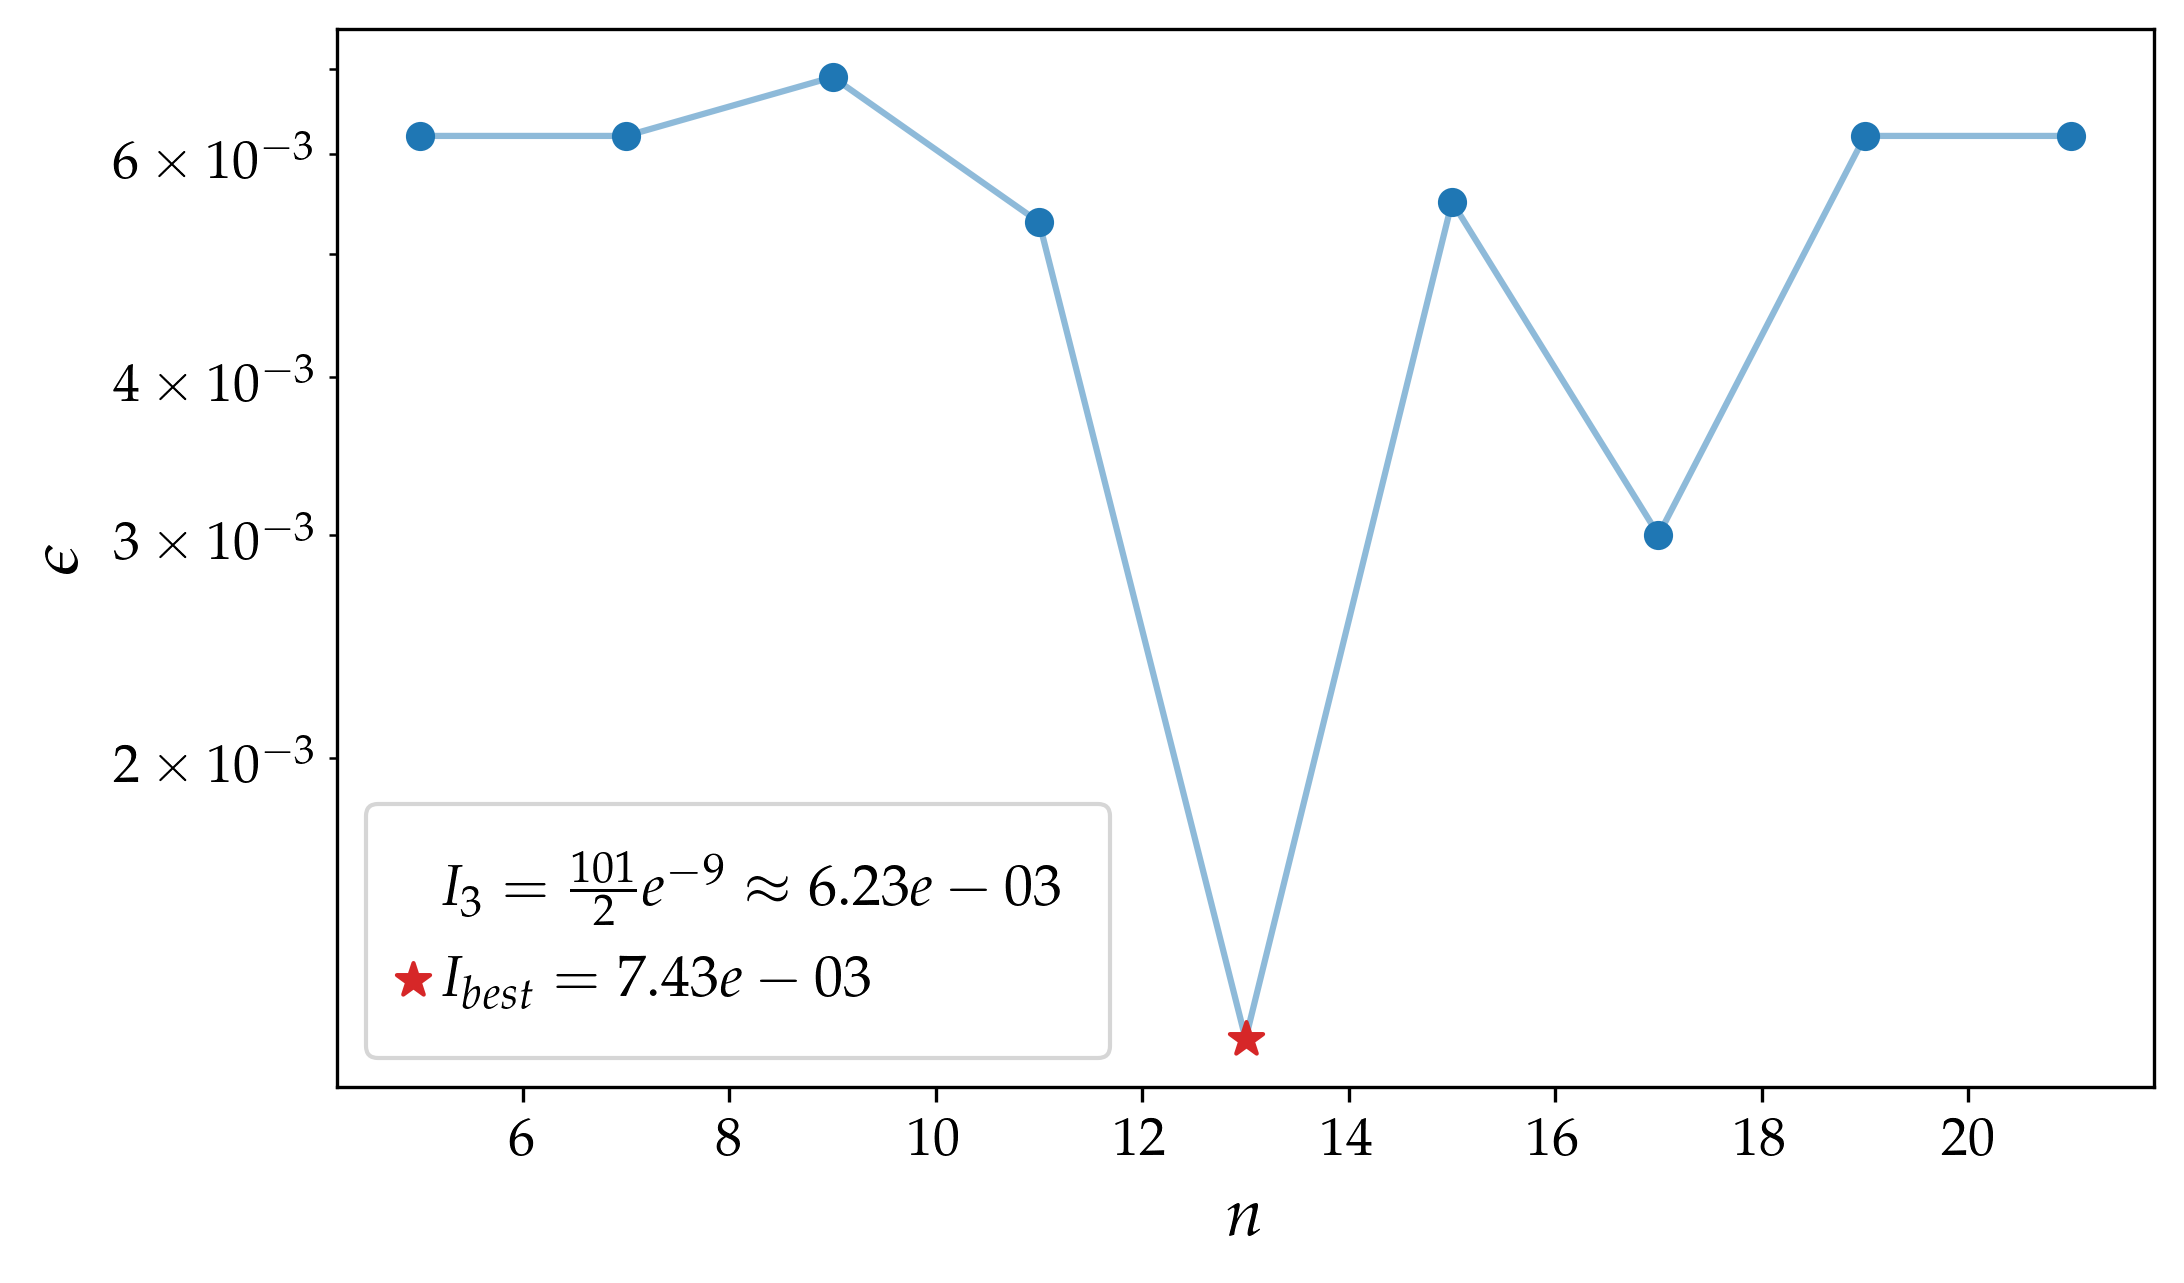

In [84]:
from int_3 import n_deg_3, true_3
from matplotlib.lines import Line2D

data = np.loadtxt('txts/int3.txt')
errs_3 = data[:, 2]
best_ind = np.argmin(data[:, 2])
I_g = data[:, 1][best_ind]

print('n --> res:')
for row in data:
    deg, res, err = row
    if deg < 10:
        print(f'    {int(deg)}  -->   {res}')
    else:
        print(f'    {int(deg)} -->   {res}')
    print(f'       -->   {err:.1e}\n')


plt.figure(figsize=(7.5, 4.5))

line, = plt.plot(n_deg_3, errs_3, alpha=0.5)
pts = plt.scatter(n_deg_3[n_deg_3!=n_deg_3[best_ind]], errs_3[errs_3!=errs_3[best_ind]], marker='o')
best = plt.scatter(n_deg_3[best_ind], errs_3[best_ind], marker='*', 
                   color='C3', zorder=5, s=70)

plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log')

proxy_true = Line2D([0], [0], color='none')
plt.legend(
    [proxy_true, best], 
    [rf'$I_3 = \frac{{101}}{{2}}e^{{-9}} \approx {true_3:.2e}$', rf'$I_{{best}} = {I_g:.2e}$'], 
    handlelength=0, 
    handletextpad=0.5,
    borderpad=0.8,       
    frameon=True
)

plt.tight_layout()
plt.savefig('plots/int_3.png')
plt.show()


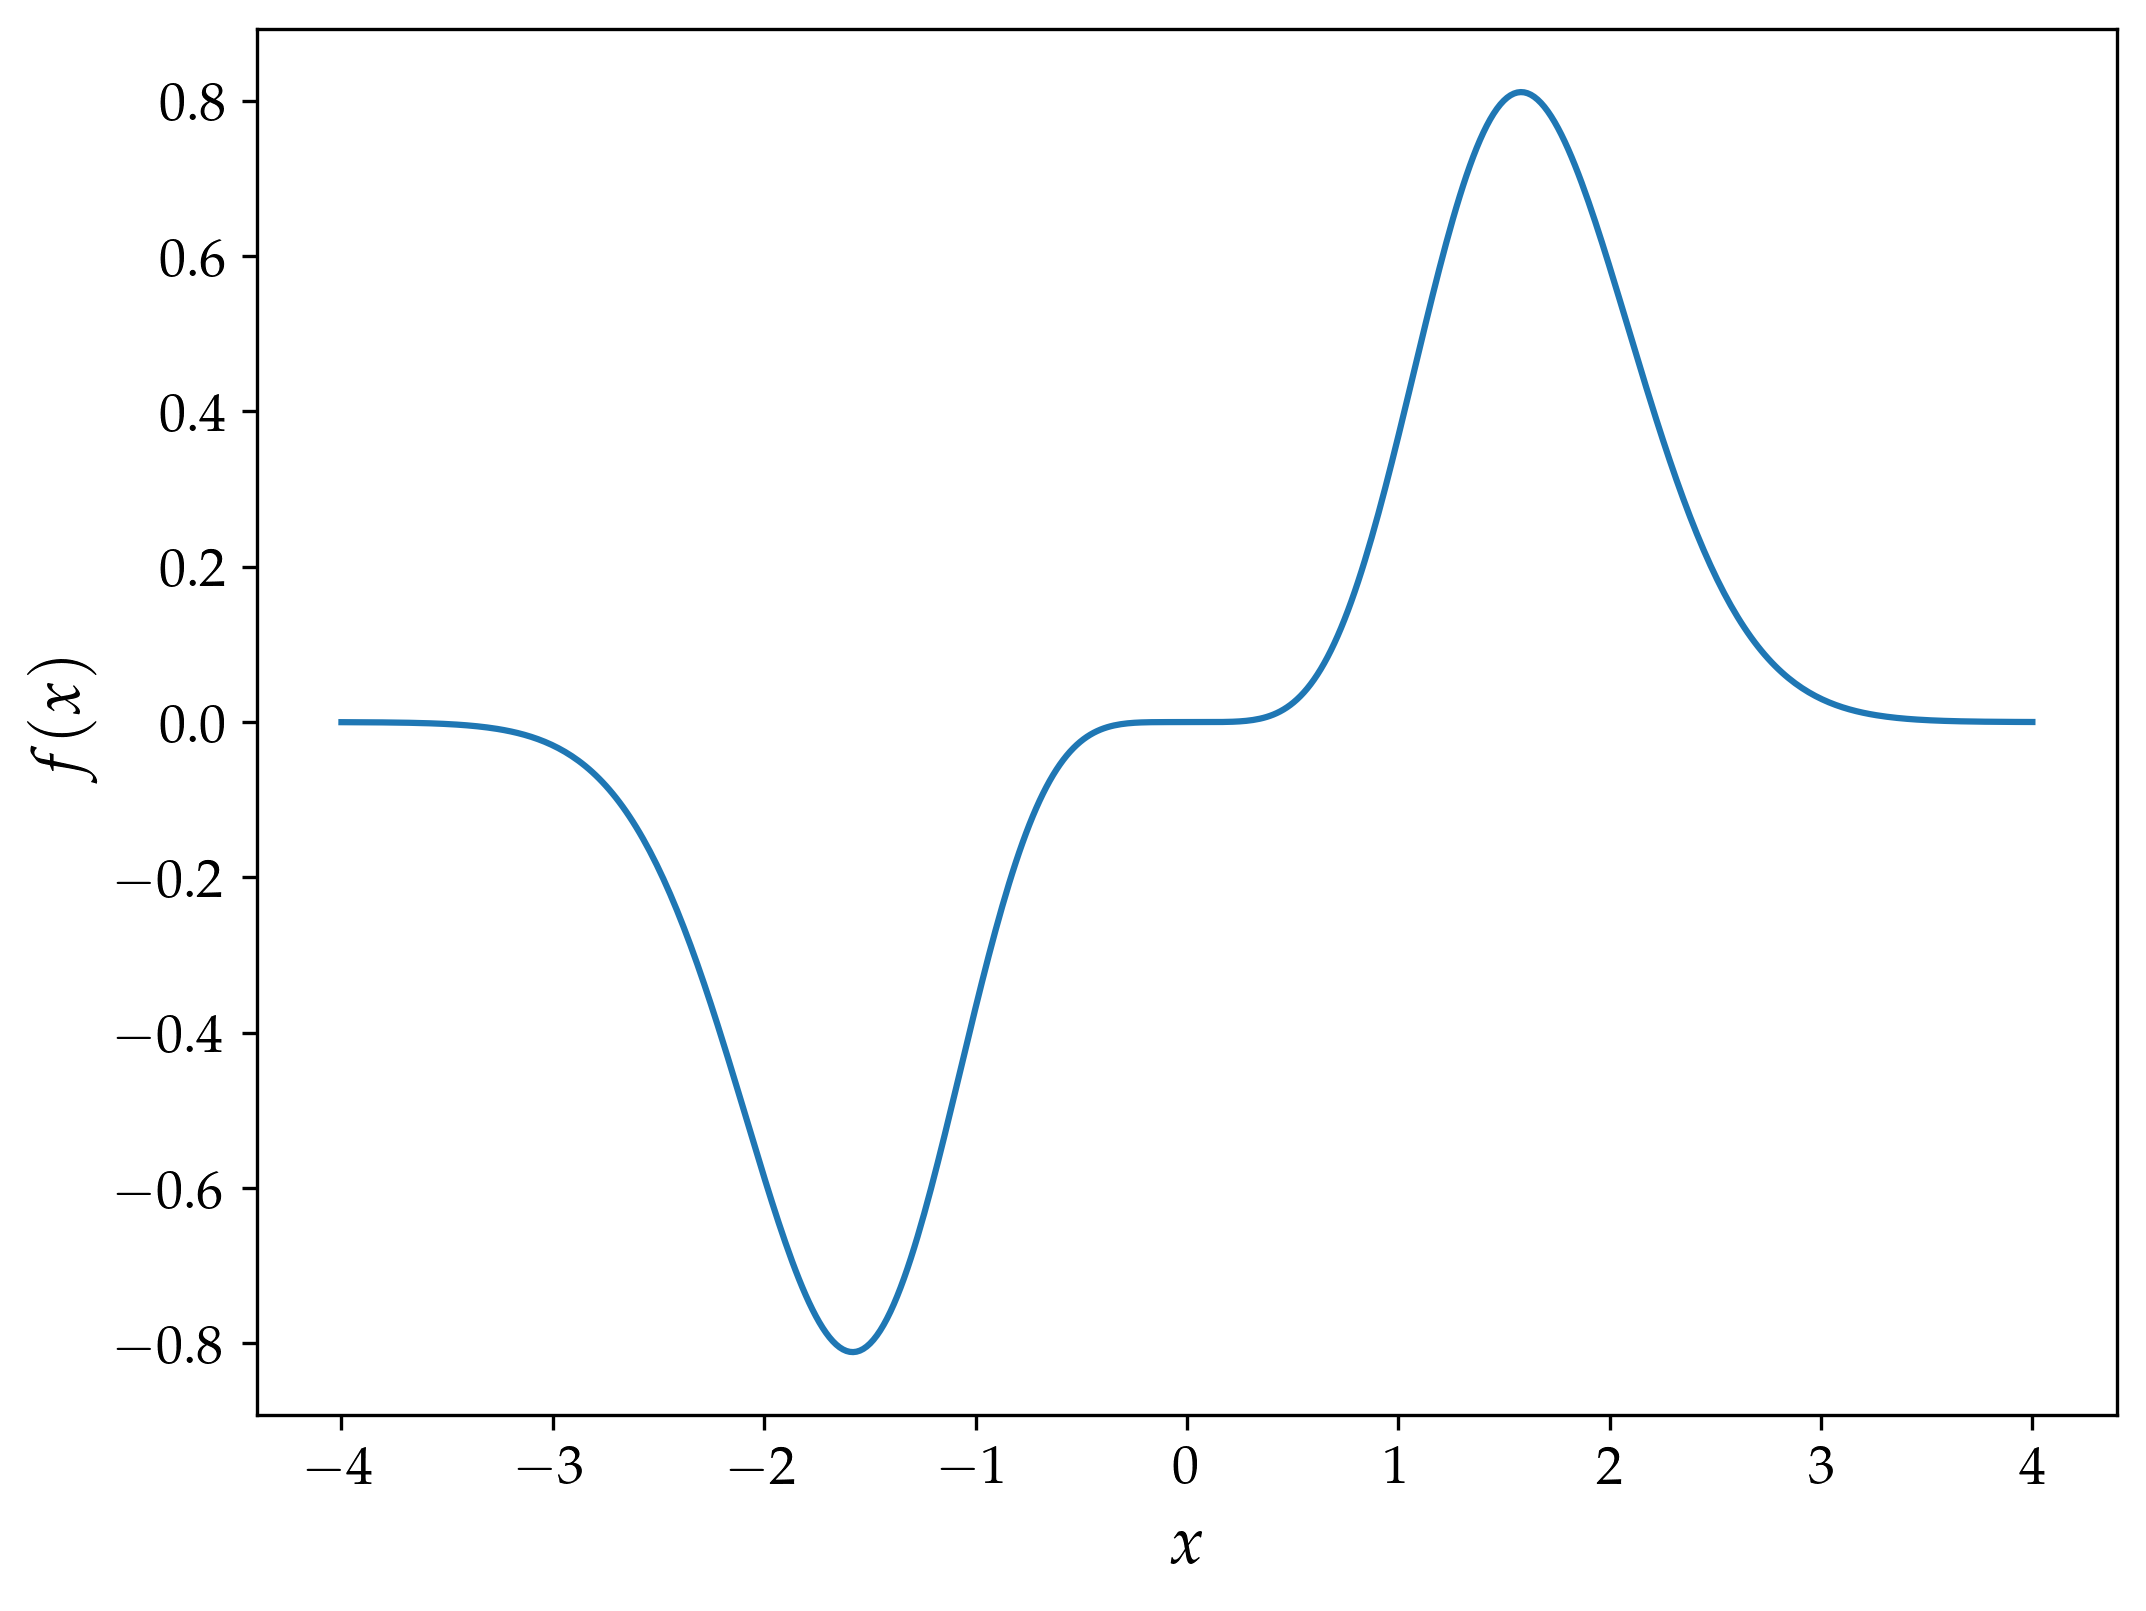

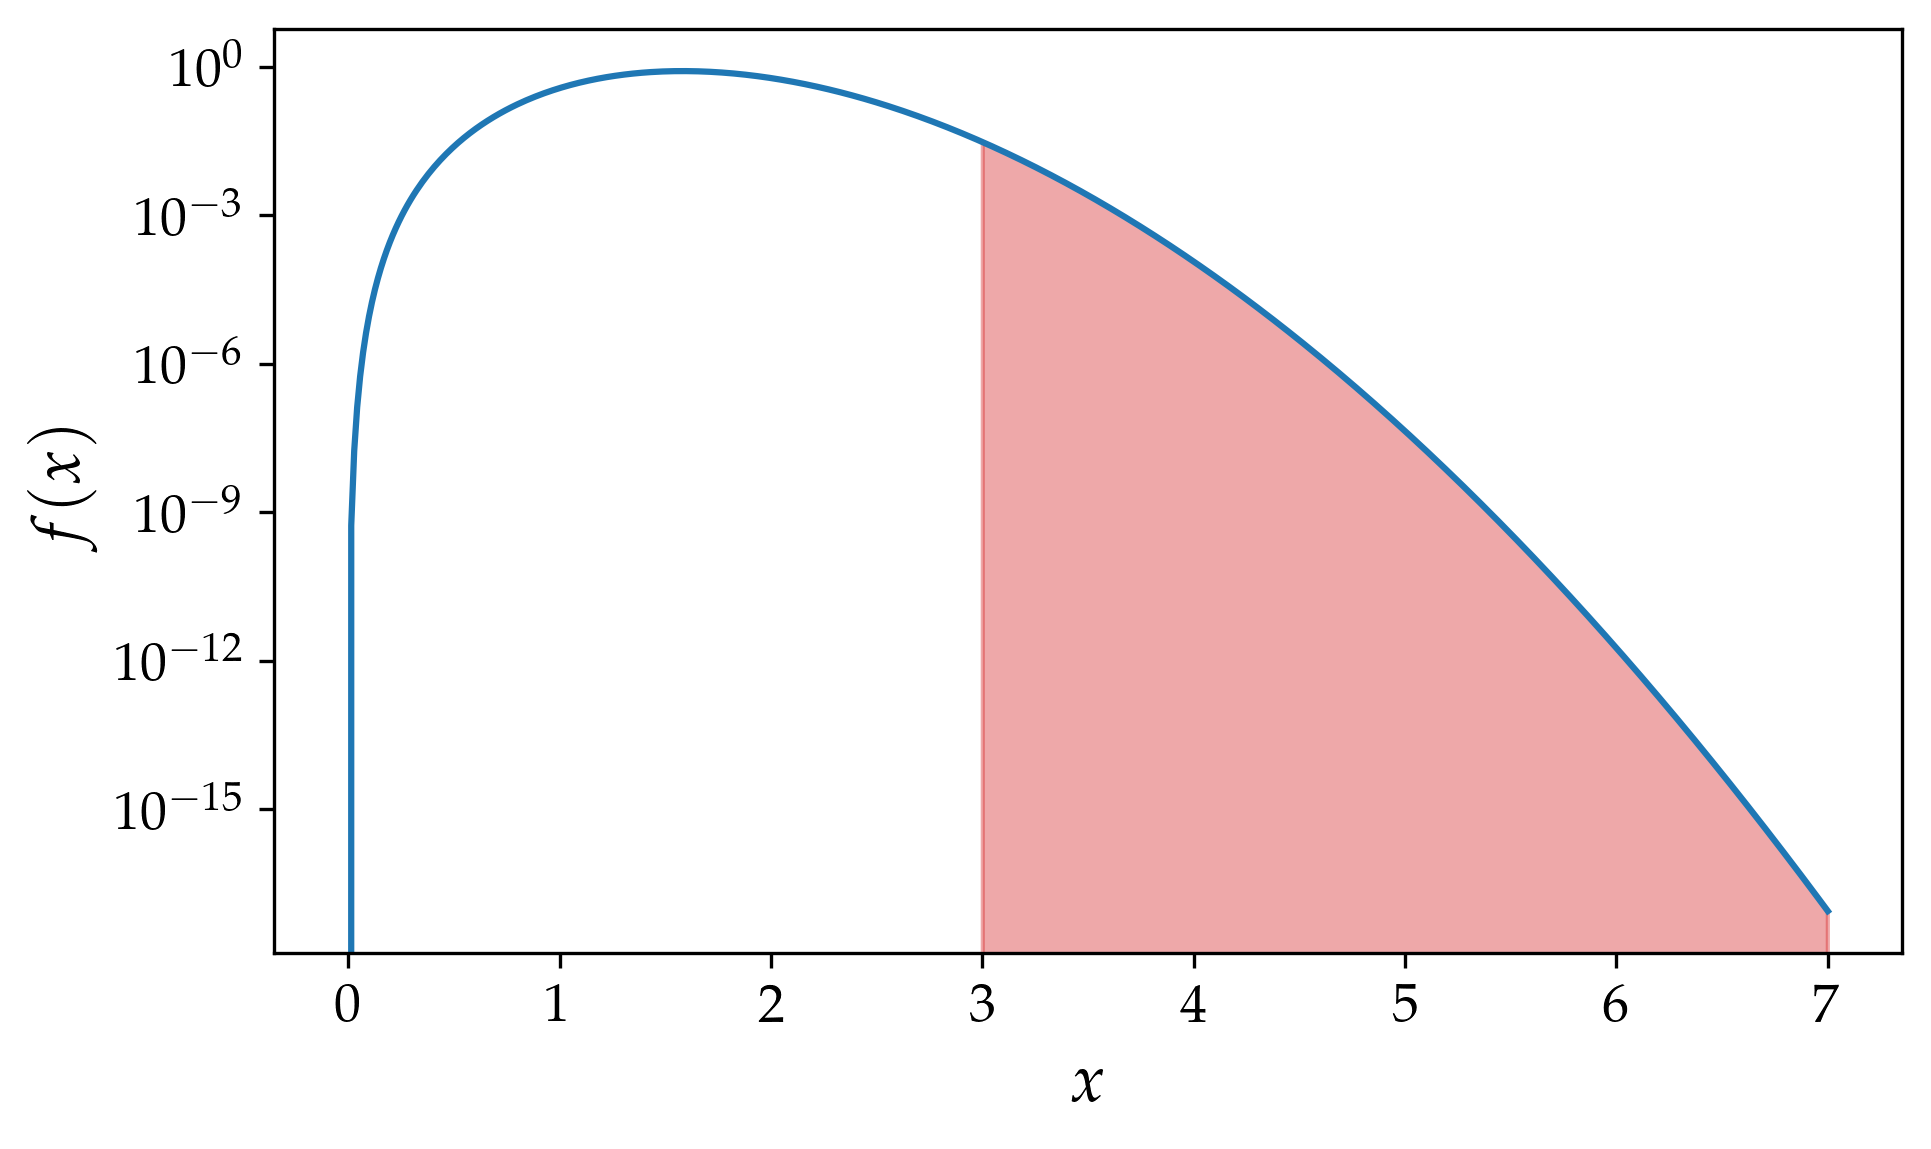

f(7) = 8.811717934414974e-18


In [85]:
func = lambda x: x**5 * np.exp(-x**2) 
xmin = 3
xmax = 4
xcoo = np.linspace(-xmax, xmax, 500)
ycoo = func(xcoo)
plt.plot()
plt.plot(xcoo, ycoo)
mask = xcoo>= 3

plt.xlabel(rf'$x$')
plt.ylabel(rf'$f(x)$')


plt.savefig('plots/func_display_tot.png')
plt.show()






xmin = 0
xmax = 7
xcoo = np.linspace(xmin, xmax, 500)
ycoo = func(xcoo)
plt.figure(figsize=(7, 4))
plt.plot()
plt.plot(xcoo, ycoo)
mask = xcoo>= 3
plt.fill_between(xcoo[mask], ycoo[mask], color='C3', alpha=0.4)
plt.yscale('log')

plt.xlabel(rf'$x$')
plt.ylabel(rf'$f(x)$')


plt.savefig('plots/func_display_part.png')
plt.show()



errs_3_trap = []
errs_3_sim = []

I_t = 0
I_s = 0


xmin, xmax = (3, xmax)
print(f'f({xmax}) = {func(xmax)}')


for deg in n_deg_3:
    res = trapezoidal(func, xmin, xmax, (xmax-xmin)/ deg)
    err = abs(res - true_3)
    errs_3_trap.append(err)
    I_t = res
    
    res = Simpson(func, xmin, xmax, (xmax-xmin)/ deg)
    err = abs(res - true_3)
    errs_3_sim.append(err)
    I_s = res


names = [
    'Gaussian quadrature',
    'Trapezoidal',
    'Simpson'
]

markers = ['o', '*', 'x']


## **Comparison between methods**

Results of the study:
     TRUE                --> I = 6.23e-03

     Gauss quadrature    --> I = 7.43e-03
                             err = 1.19e-03

     Trapezoidal         --> I = 6.62e-03
                             err = 3.90e-04

     Simpson             --> I = 6.24e-03
                             err = 8.82e-06



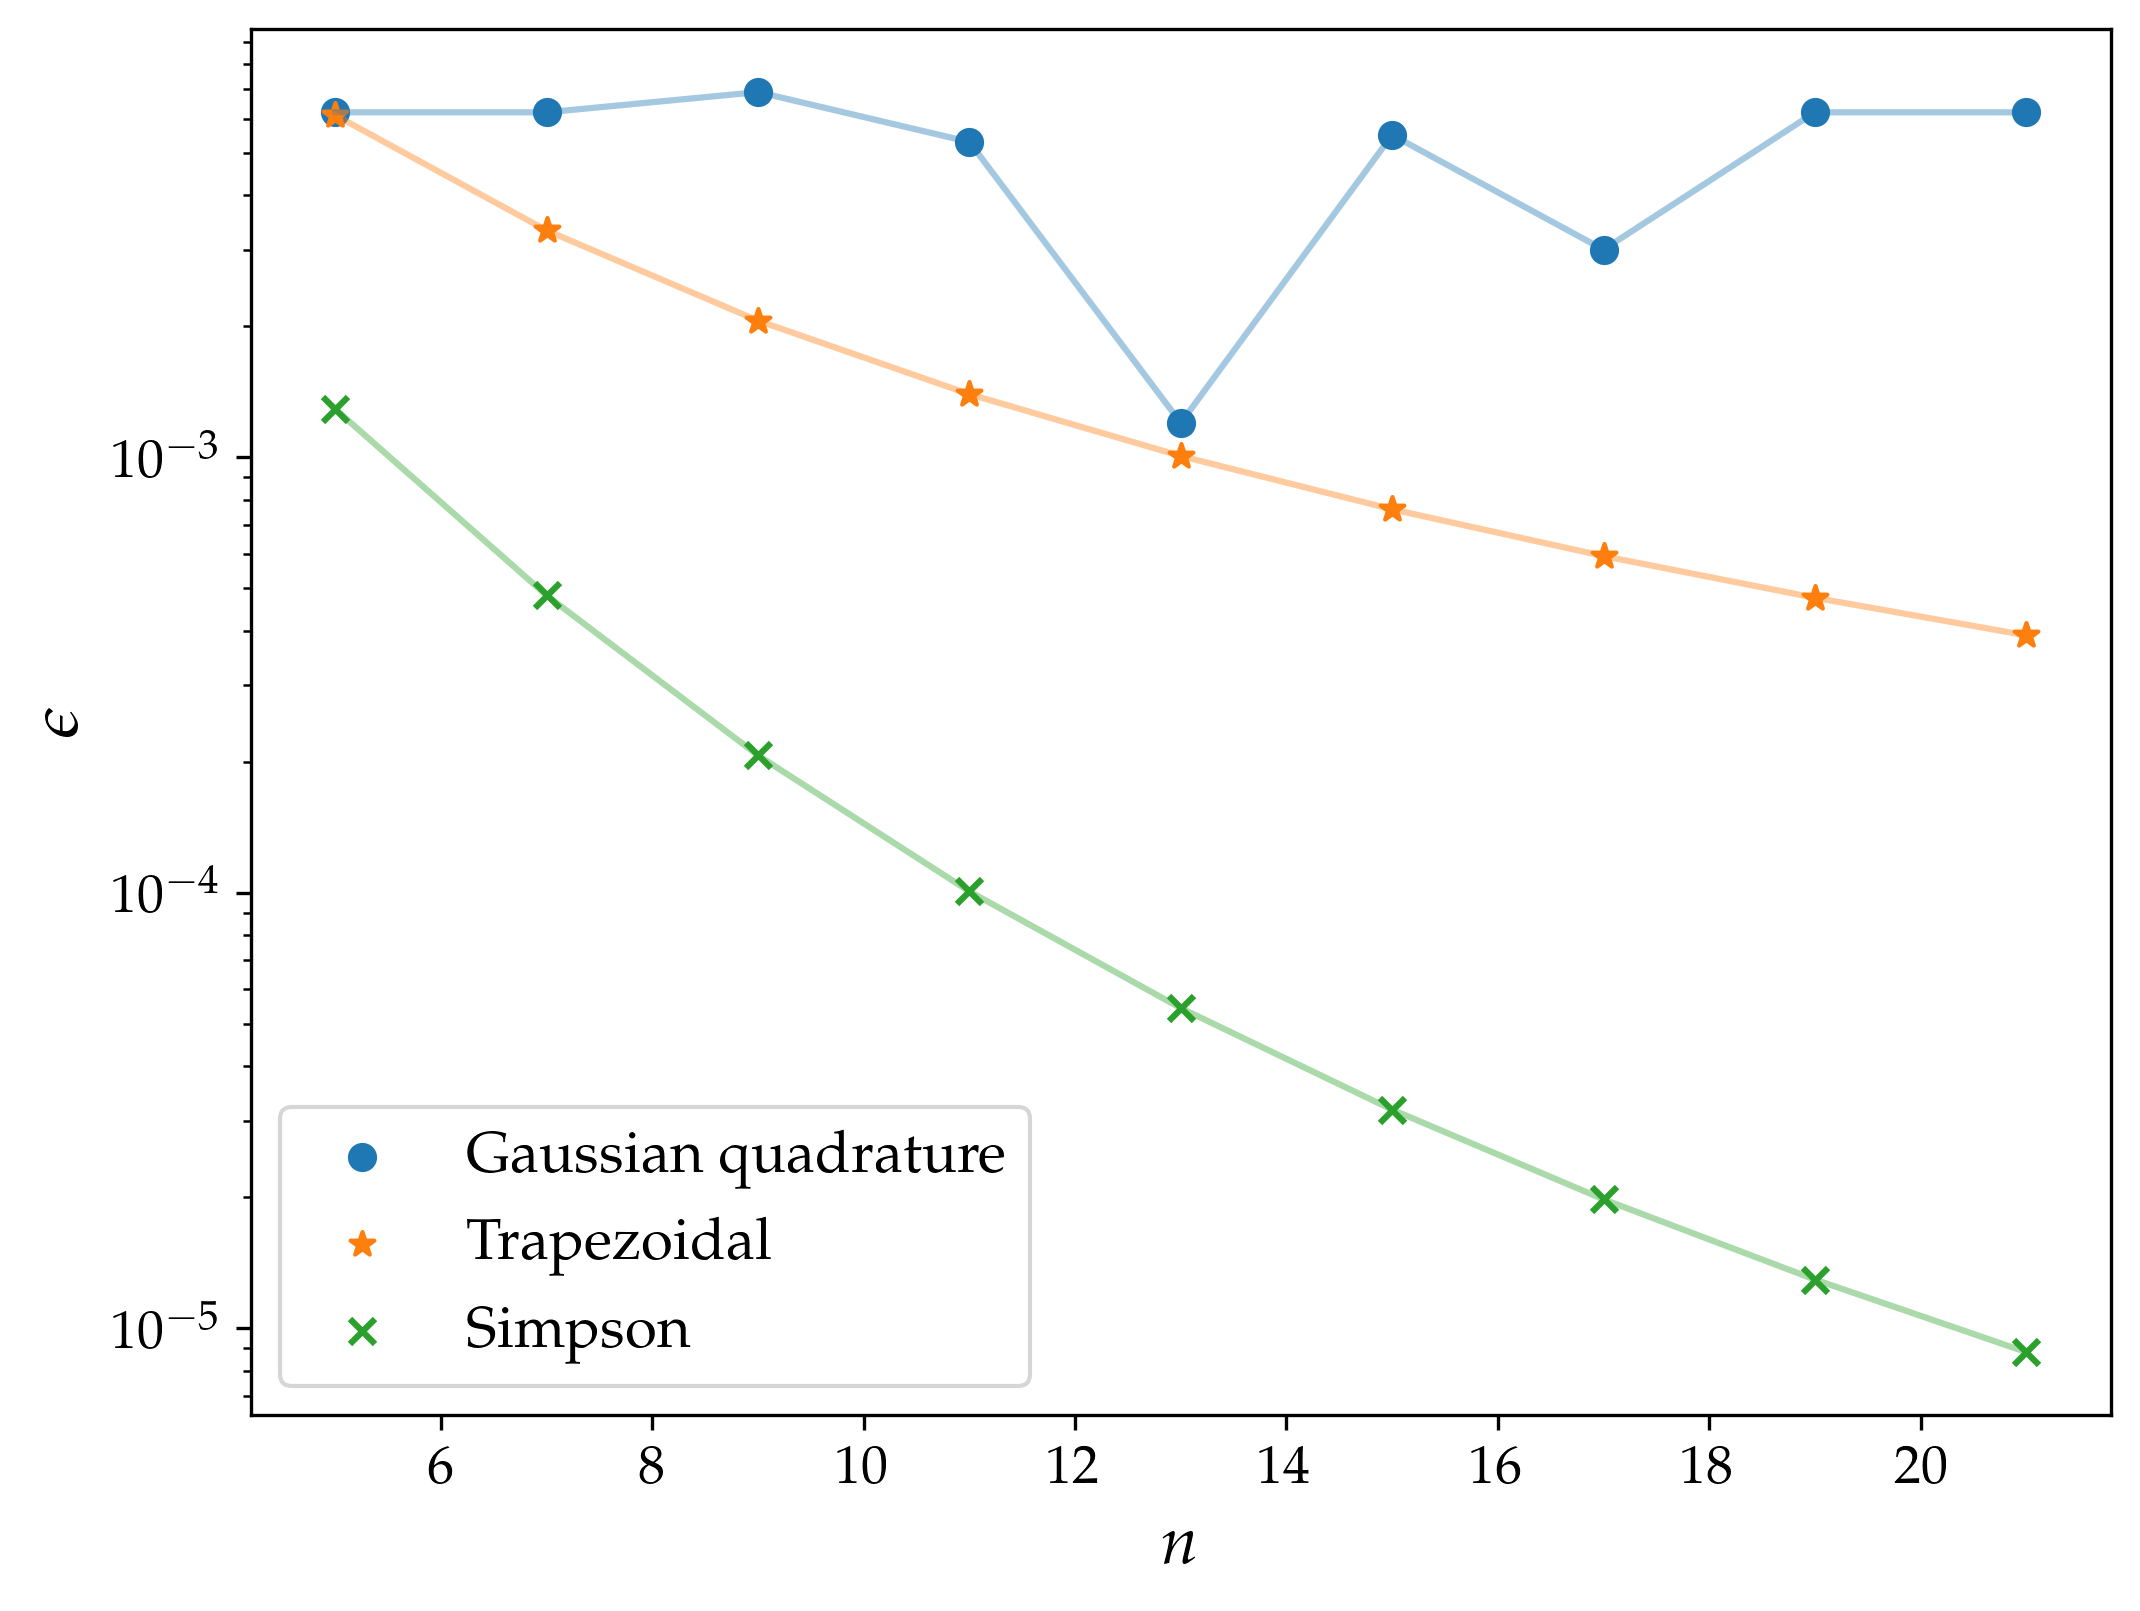

In [86]:
print('Results of the study:')
print(f'     TRUE                --> I = {true_3:.2e}')
print()
print(f'     Gauss quadrature    --> I = {I_g:.2e}')
print(f'                             err = {abs(true_3 - I_g):.2e}')
print()
print(f'     Trapezoidal         --> I = {I_t:.2e}')
print(f'                             err = {abs(true_3 - I_t):.2e}')
print()
print(f'     Simpson             --> I = {I_s:.2e}')
print(f'                             err = {abs(true_3 - I_s):.2e}')
print()


for n, ys in enumerate([errs_3, errs_3_trap, errs_3_sim]):
    plt.plot(n_deg_3, ys, alpha=0.4)
    plt.scatter(n_deg_3, ys, label=names[n], marker=markers[n])
plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.legend()

plt.savefig('plots/confr.png')
plt.show()


## **Fit of the slope of integrals**

In [87]:

errs_3_trap = []
errs_3_sim = []
n_deg_3_mod = np.arange(1, 100, 2)
for deg in n_deg_3_mod:
    res = trapezoidal(func, xmin, xmax, (xmax-xmin)/ deg)
    err = abs(res - true_3)
    errs_3_trap.append(err)
    
    res = Simpson(func, xmin, xmax, (xmax-xmin)/ deg)
    err = abs(res - true_3)
    errs_3_sim.append(err)


dof = 38

a = -1.99e+00 +/- 8.346e-01
b = -7.72e-01 +/- 1.461e+00

Chi2 = 0.00
p-val = 1.00


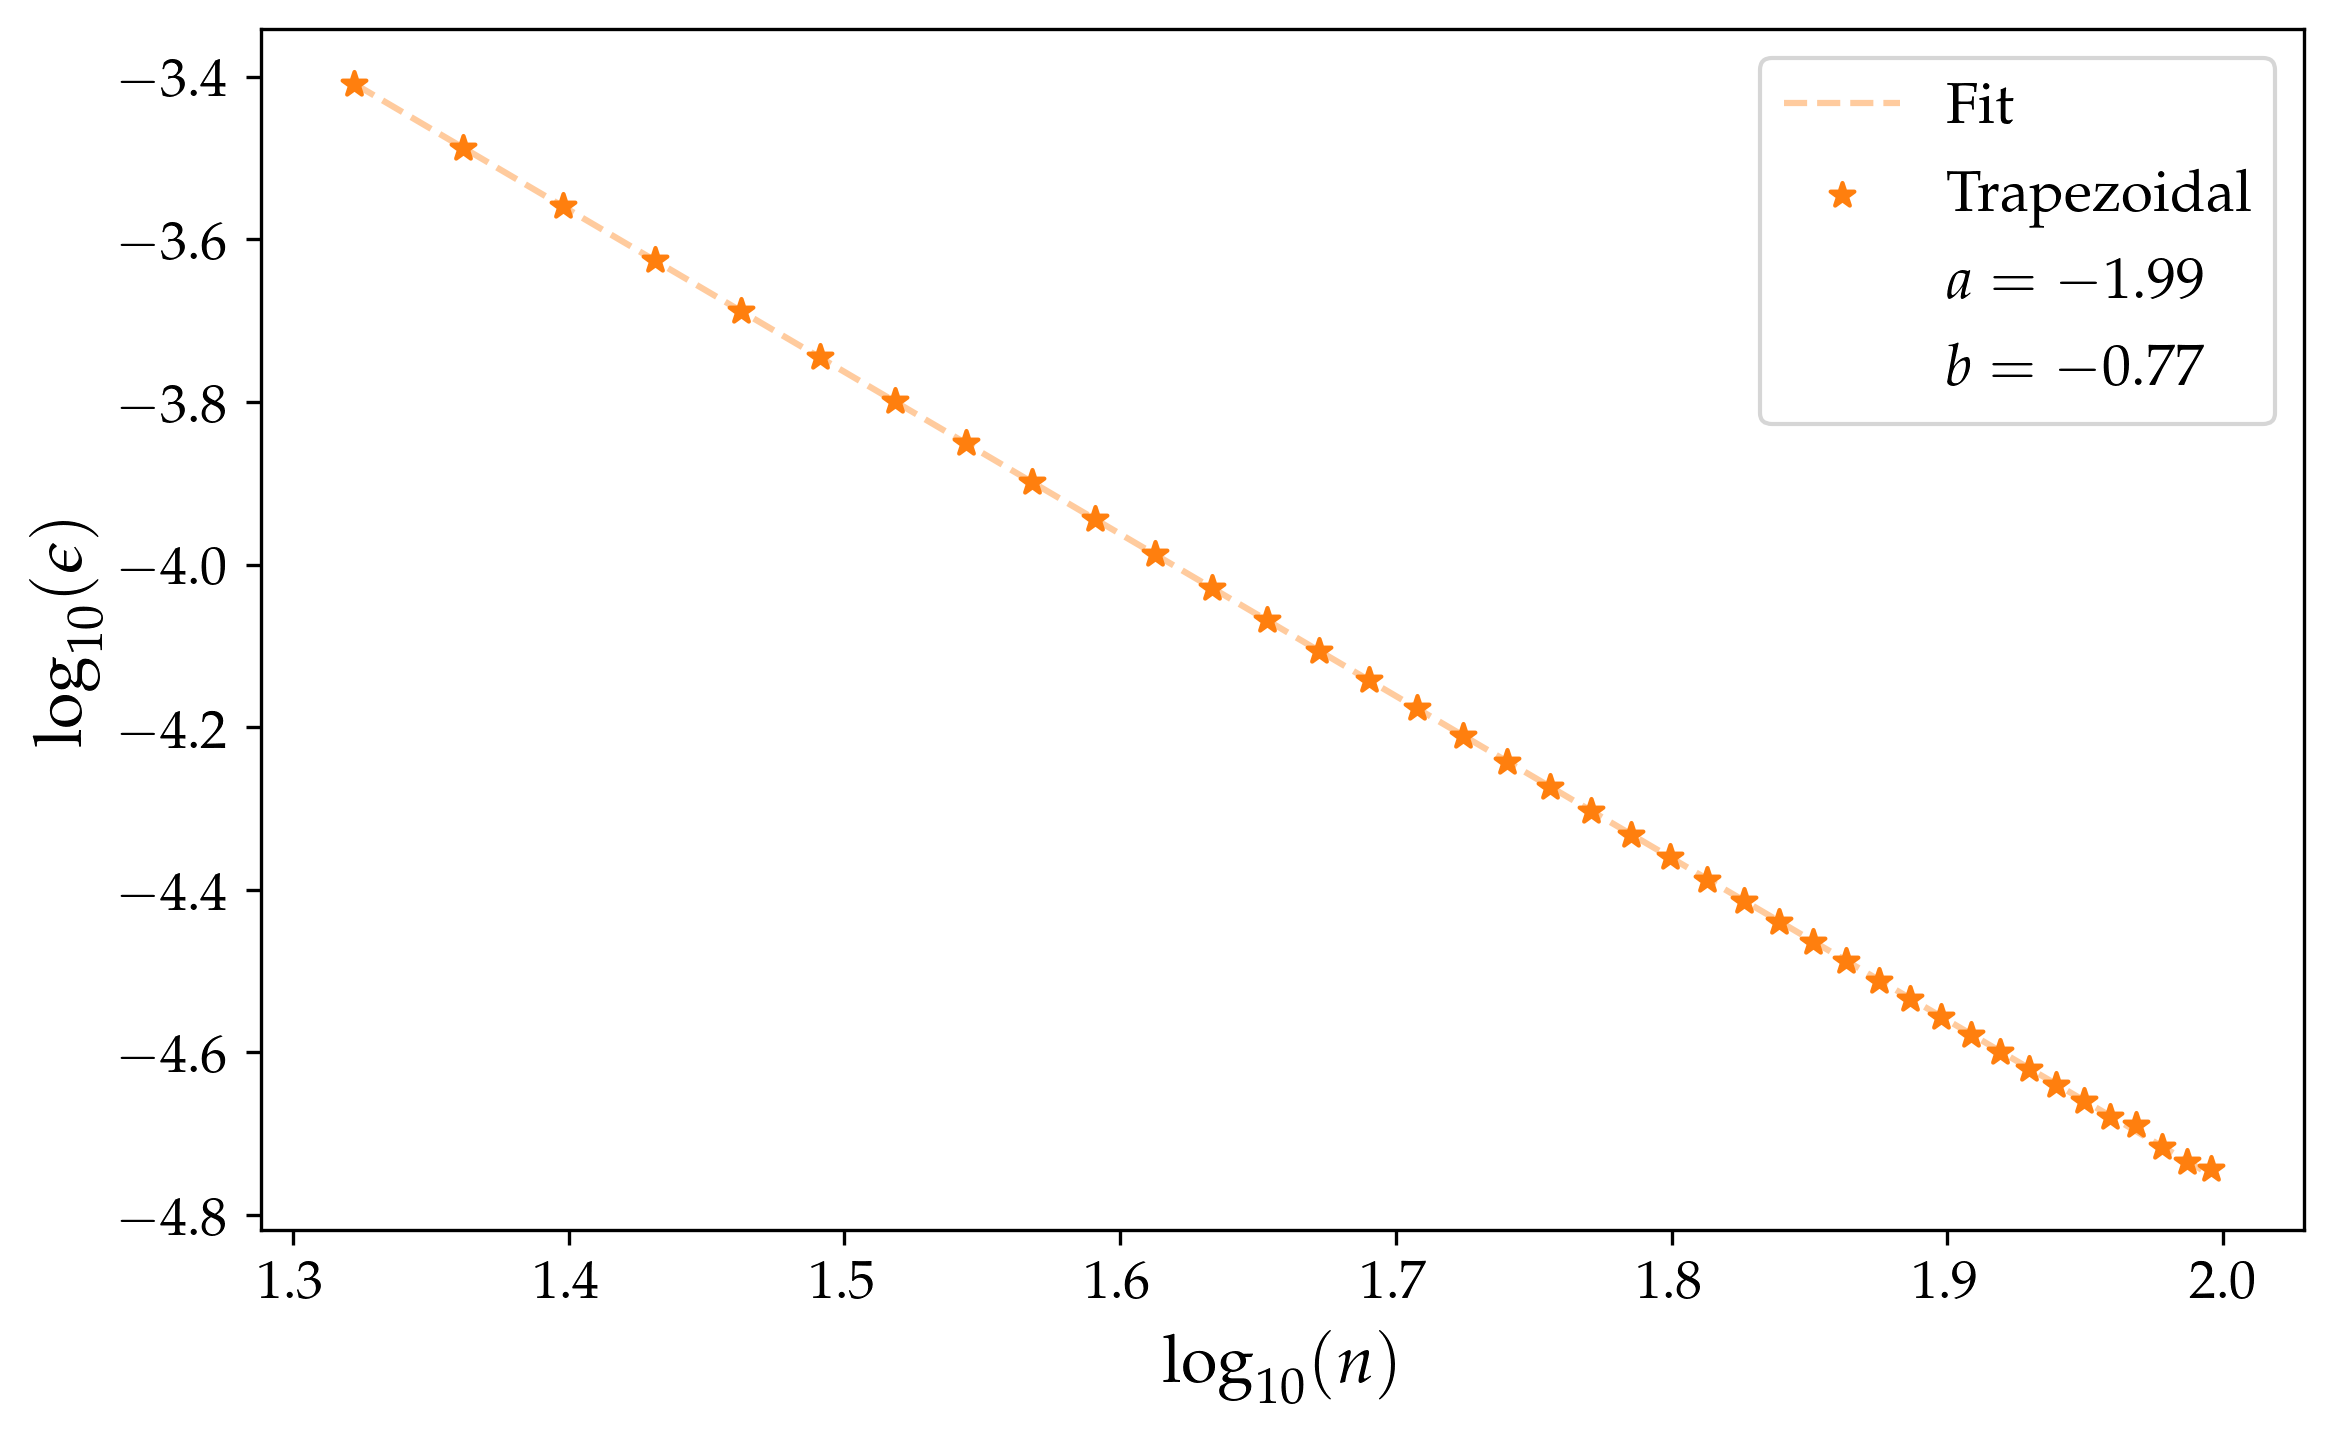

dof = 38

a = -3.91e+00 +/- 8.346e-01
b = 1.20e-01 +/- 1.461e+00

Chi2 = 0.00
p-val = 1.00


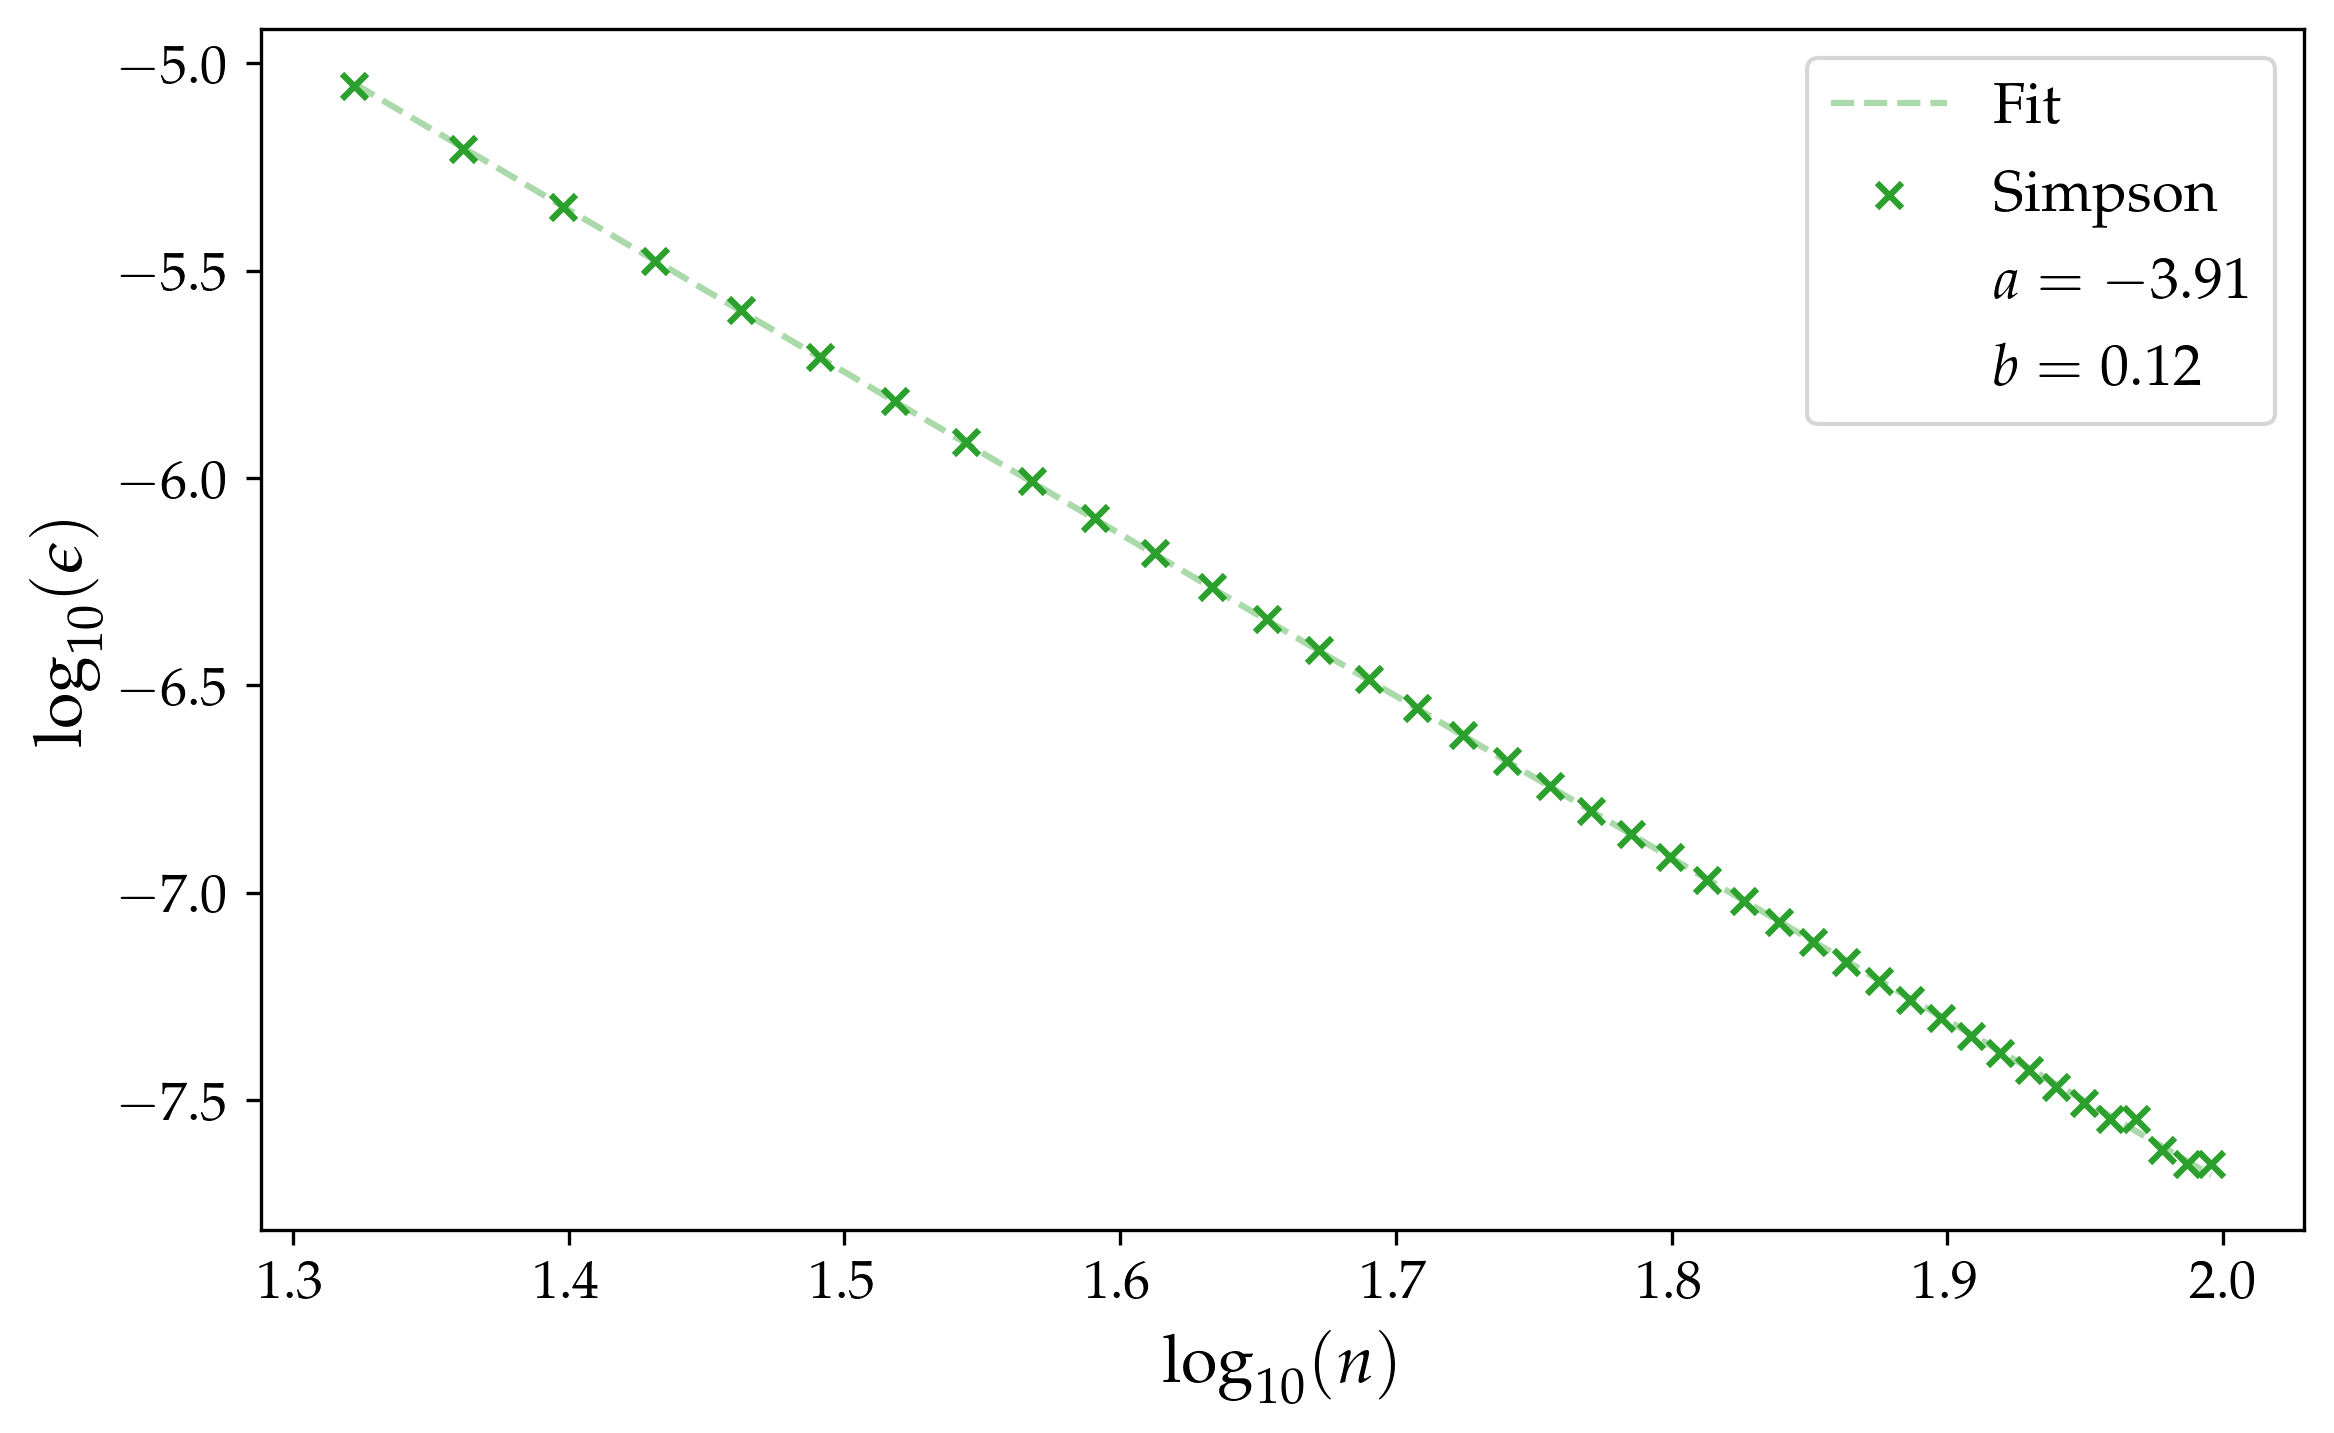

In [88]:
from lib_fitting import lin_fit

mask = np.array(errs_3_sim) < 1e-5
err_trap = np.log10(np.array(errs_3_trap)[mask])
err_simp = np.log10(np.array(errs_3_sim)[mask])
x = np.log10(np.array(n_deg_3_mod)[mask])

results = []
for n, y in enumerate((err_trap, err_simp)):
    results.append(
        lin_fit(x, y, name_points=names[n+1], mar=markers[n+1], col=f'C{n+1}',
                labels=(r'$\log_{10}(n)$', r'$\log_{10}(\epsilon)$'))
                )


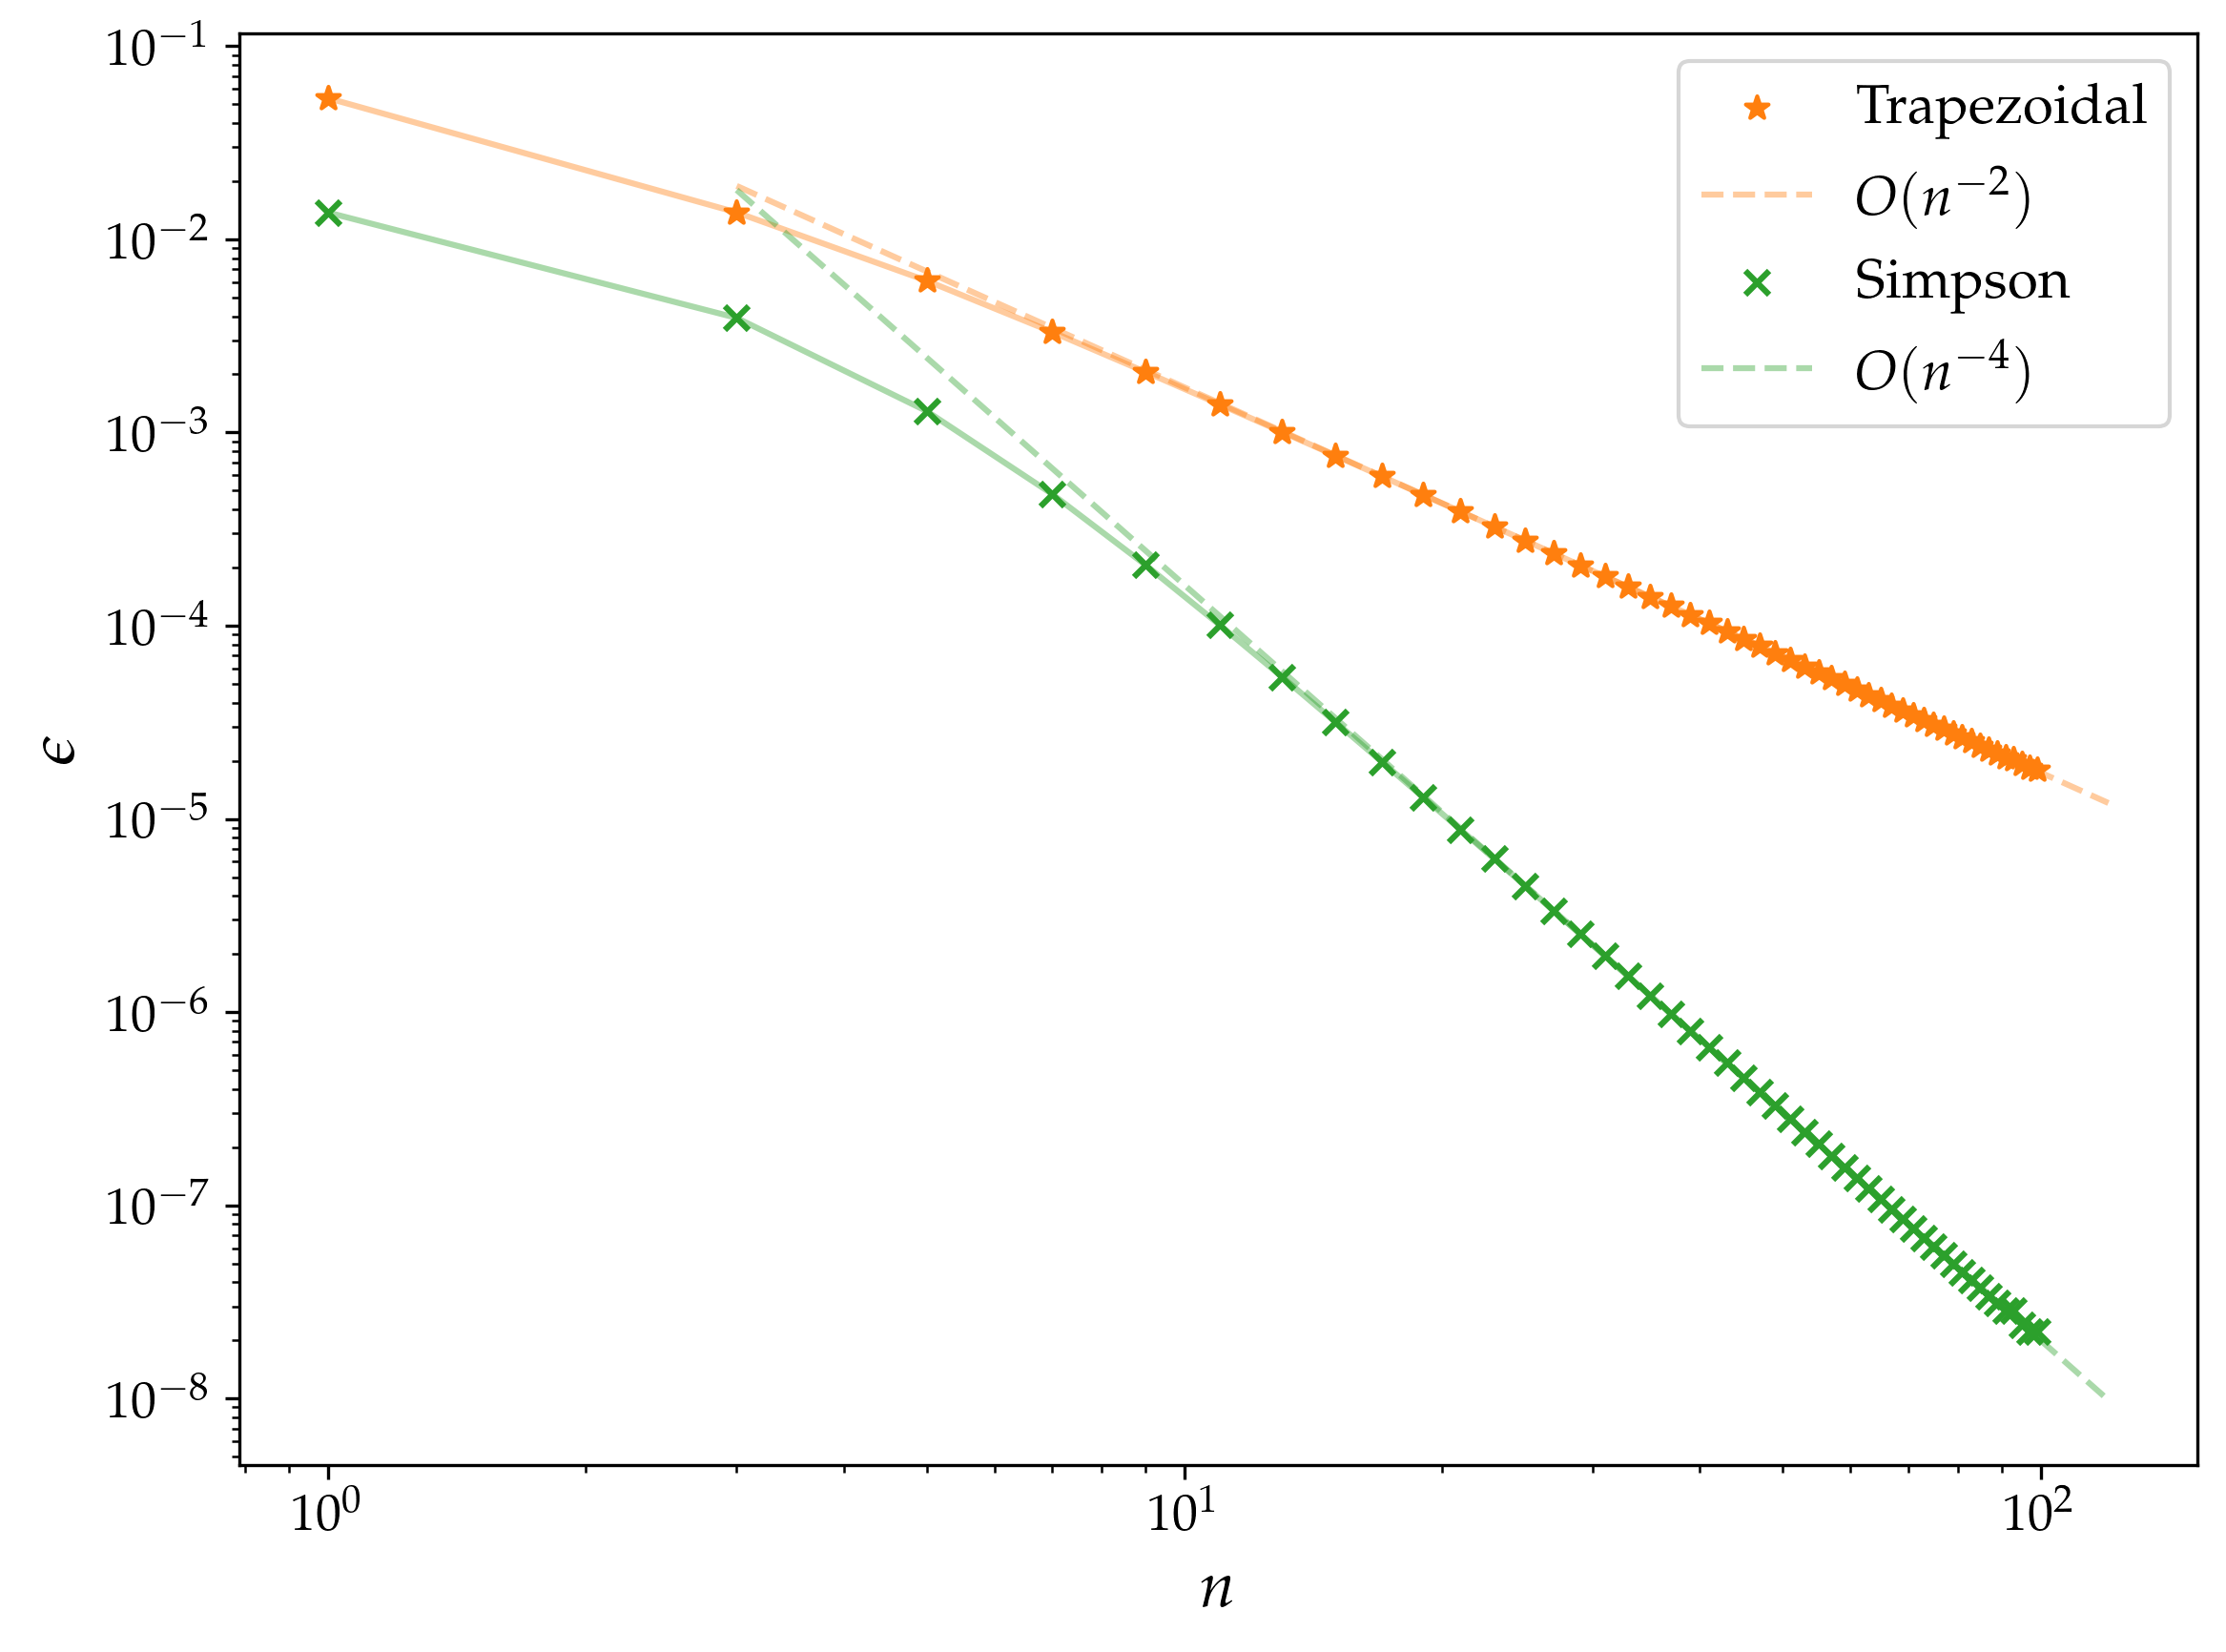

In [89]:
for n, ys in enumerate([errs_3_trap, errs_3_sim]):
    a, b = results[n][0]
    p, k = (a, 10**b)
    n_coo_lin = np.linspace(3, 120)
    lin_ = k * n_coo_lin**p
    
    plt.plot(n_deg_3_mod, ys, alpha=0.4, color=f'C{n+1}')
    plt.scatter(n_deg_3_mod, ys, label=names[n+1], marker=markers[n+1], color=f'C{n+1}')
    plt.plot(n_coo_lin, lin_, ls='--', color=f'C{n+1}', alpha=0.4, label=rf'$O(n^{{{round(p)}}})$')

plt.xlabel(rf'$n$')
plt.ylabel(rf'$\epsilon$')
plt.yscale('log') 
plt.xscale('log') 
plt.legend()
plt.tight_layout()

plt.savefig('plots/confr_fit')
plt.show()